## 2. Dataset Loading

This step loads the smart manufacturing dataset from CSV into a Pandas DataFrame.


In [160]:
import pandas as pd

df = pd.read_csv("smart_manufacturing_ml_dataset.csv")

df.head()

,machine_id,plant,production_line,machine_type,shift,operator_experience_years,machine_age_years,ambient_temperature_c,humidity_pct,vibration_mm_s,hydraulic_pressure_bar,motor_current_a,rpm,production_rate_units_hr,defect_rate_pct,downtime_hours_30d,maintenance_count,days_since_maintenance,power_factor,oil_temperature_c,bearing_temperature_c,load_percent,noise_db,material_grade,lubricant_type,supplier_tier,inspection_status,batch_size,machine_energy_kwh,maintenance_risk
0,118835,Chennai,L3,CNC,Afternoon,9.80,12.55,29.25,98.00,3.116,6.53,19.64,2335.8,112.9,2.625,3.48,3,19.7,0.953,51.09,44.25,76.29,74.60,HighStrength,Synthetic,NaN,Rework,344,39.19,Medium
1,100736,Hyderabad,L1,Milling,Afternoon,0.20,9.14,27.87,63.55,2.284,7.81,30.47,2477.5,107.2,1.382,0.81,1,31.0,0.879,60.54,50.44,73.22,69.54,Standard,Synthetic,Local,Pass,382,40.39,Low
2,120211,Ahmedabad,L1,Lathe,Night,9.68,3.82,27.89,57.28,2.662,7.27,32.25,3558.0,146.4,7.156,0.44,1,10.3,0.942,48.81,46.10,80.38,75.77,Standard,Synthetic,Local,Pass,297,47.36,Low
3,118587,Chennai,L5,Robot,Afternoon,10.70,7.11,22.20,68.56,1.457,7.64,38.33,3419.4,94.6,7.787,1.02,1,130.7,0.903,55.07,42.14,71.95,70.10,Recycled,Bio,Tier3,Pass,773,58.99,Medium
4,105358,Pune,L1,Compressor,Morning,5.13,2.73,31.78,79.86,2.873,8.63,30.06,2456.5,78.3,9.551,0.24,1,75.6,0.912,NaN,55.14,58.85,70.34,Recycled,Mineral,Tier2,Pass,984,39.78,High


# Smart Manufacturing Machine Learning Project

## Review 1

This project analyzes a smart manufacturing dataset containing machine,
environmental, production, maintenance, and operational information.

Two machine learning tasks are performed:

1. Regression — Predict machine energy consumption (`machine_energy_kwh`)
2. Classification — Predict maintenance risk (`maintenance_risk`)

The project covers:
- Exploratory Data Analysis (EDA)
- Data Cleaning
- Missing Value Treatment
- Duplicate Detection
- Outlier Detection
- Feature Engineering
- Categorical Encoding
- Feature Scaling
- Regression
- Classification
- Model Evaluation
- Hyperparameter Tuning
- Cross-Validation

In [161]:
# ================================
# 1. IMPORTS & CONFIGURATION
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder,
    OrdinalEncoder,
    PolynomialFeatures
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import (
    DecisionTreeRegressor,
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.svm import (
    SVR,
    SVC
)

from sklearn.neighbors import (
    KNeighborsRegressor,
    KNeighborsClassifier
)

from sklearn.naive_bayes import GaussianNB

from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Reproducibility
RANDOM_STATE = 42

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Dataset Loading

The dataset is loaded into a pandas DataFrame for further analysis.

The regression target is `machine_energy_kwh`, representing machine
energy consumption.

The classification target is `maintenance_risk`, representing the
maintenance risk category of each machine.

In [162]:
# Load dataset

df = pd.read_csv("smart_manufacturing_ml_dataset.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


### 2.1 Previewing Raw Data

This step previews the first five rows of the dataset to inspect feature columns and sample values.


In [163]:
df.head()

,machine_id,plant,production_line,machine_type,shift,operator_experience_years,machine_age_years,ambient_temperature_c,humidity_pct,vibration_mm_s,hydraulic_pressure_bar,motor_current_a,rpm,production_rate_units_hr,defect_rate_pct,downtime_hours_30d,maintenance_count,days_since_maintenance,power_factor,oil_temperature_c,bearing_temperature_c,load_percent,noise_db,material_grade,lubricant_type,supplier_tier,inspection_status,batch_size,machine_energy_kwh,maintenance_risk
0,118835,Chennai,L3,CNC,Afternoon,9.80,12.55,29.25,98.00,3.116,6.53,19.64,2335.8,112.9,2.625,3.48,3,19.7,0.953,51.09,44.25,76.29,74.60,HighStrength,Synthetic,NaN,Rework,344,39.19,Medium
1,100736,Hyderabad,L1,Milling,Afternoon,0.20,9.14,27.87,63.55,2.284,7.81,30.47,2477.5,107.2,1.382,0.81,1,31.0,0.879,60.54,50.44,73.22,69.54,Standard,Synthetic,Local,Pass,382,40.39,Low
2,120211,Ahmedabad,L1,Lathe,Night,9.68,3.82,27.89,57.28,2.662,7.27,32.25,3558.0,146.4,7.156,0.44,1,10.3,0.942,48.81,46.10,80.38,75.77,Standard,Synthetic,Local,Pass,297,47.36,Low
3,118587,Chennai,L5,Robot,Afternoon,10.70,7.11,22.20,68.56,1.457,7.64,38.33,3419.4,94.6,7.787,1.02,1,130.7,0.903,55.07,42.14,71.95,70.10,Recycled,Bio,Tier3,Pass,773,58.99,Medium
4,105358,Pune,L1,Compressor,Morning,5.13,2.73,31.78,79.86,2.873,8.63,30.06,2456.5,78.3,9.551,0.24,1,75.6,0.912,NaN,55.14,58.85,70.34,Recycled,Mineral,Tier2,Pass,984,39.78,High


### 2.2 Dataset Shape & Row Count

This step checks the total number of observations (rows) present in the dataset.


In [164]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 22260
Number of columns: 30


### 2.3 Feature Data Types Inspection

This step inspects the data type of each column and summarizes the counts of numerical vs categorical attributes.


In [165]:
df.dtypes

machine_id                     int64
plant                         object
production_line               object
machine_type                  object
shift                         object
operator_experience_years    float64
machine_age_years            float64
ambient_temperature_c        float64
humidity_pct                 float64
vibration_mm_s               float64
hydraulic_pressure_bar       float64
motor_current_a              float64
rpm                          float64
production_rate_units_hr     float64
defect_rate_pct              float64
downtime_hours_30d           float64
maintenance_count              int64
days_since_maintenance       float64
power_factor                 float64
oil_temperature_c            float64
bearing_temperature_c        float64
load_percent                 float64
noise_db                     float64
material_grade                object
lubricant_type                object
supplier_tier                 object
inspection_status             object
b

### 2.3 Feature Data Types Inspection

This step inspects the data type of each column and summarizes the counts of numerical vs categorical attributes.


In [166]:
df.dtypes.value_counts()

float64    18
object      9
int64       3
Name: count, dtype: int64

### 2.4 Initial Missing Values Check

This step computes the total number of missing values for each attribute in the raw dataset.


In [167]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

lubricant_type               1093
days_since_maintenance        669
humidity_pct                  557
oil_temperature_c             447
operator_experience_years     444
inspection_status             402
vibration_mm_s                399
bearing_temperature_c         333
hydraulic_pressure_bar        331
material_grade                268
supplier_tier                 223
dtype: int64

In [168]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing Percentage", ascending=False)

missing_summary

,Missing Count,Missing Percentage
lubricant_type,1093,4.91
days_since_maintenance,669,3.01
humidity_pct,557,2.50
oil_temperature_c,447,2.01
operator_experience_years,444,1.99
inspection_status,402,1.81
vibration_mm_s,399,1.79
bearing_temperature_c,333,1.50
hydraulic_pressure_bar,331,1.49
material_grade,268,1.20


### 2.5 Initial Duplicate Check

This step checks for identical duplicate rows across the raw dataset.


In [169]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 260


### 2.6 Numerical Feature Descriptive Statistics

This step generates summary statistics including mean, standard deviation, min, max, and quantiles for all numerical features.


In [170]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
machine_id,22260.0,110999.023001,6351.648929,100001.000,105502.75000,110997.500,116500.2500,122000.000000
operator_experience_years,21816.0,6.475534,3.147727,0.200,4.26000,6.430,8.6200,20.000000
machine_age_years,22260.0,6.381268,3.536081,0.200,3.75750,5.740,8.3300,18.000000
ambient_temperature_c,22260.0,28.998906,4.498104,12.020,25.98000,29.020,32.0500,50.060000
humidity_pct,21703.0,62.135863,14.869514,20.000,51.95000,62.100,72.4100,98.000000
vibration_mm_s,21861.0,2.538027,2.182686,0.207,1.59900,2.213,3.0400,68.854809
hydraulic_pressure_bar,21929.0,7.399726,1.096907,3.000,6.66000,7.400,8.1400,11.650000
motor_current_a,22260.0,31.151957,8.341988,8.000,25.69750,31.180,36.4425,108.516390
rpm,22260.0,2800.749470,550.226441,900.000,2427.40000,2795.350,3171.0250,4500.000000
production_rate_units_hr,22260.0,118.210790,30.285837,25.000,97.80000,118.000,138.2000,288.491168


### 2.7 Classification Target Class Counts

This step examines the frequency and percentage distribution of categories in the maintenance_risk target.


In [171]:
print(df["maintenance_risk"].value_counts())

maintenance_risk
Low       9958
Medium    8125
High      4177
Name: count, dtype: int64


### 2.7 Classification Target Class Counts

This step examines the frequency and percentage distribution of categories in the maintenance_risk target.


In [172]:
print(df["maintenance_risk"].value_counts(normalize=True).mul(100).round(2))

maintenance_risk
Low       44.73
Medium    36.50
High      18.76
Name: proportion, dtype: float64


### 2.8 Regression Target Summary Statistics

This step computes descriptive summary statistics for the machine_energy_kwh continuous target feature.


In [173]:
df["machine_energy_kwh"].describe()

count    22260.000000
mean        51.570762
std         11.139477
min         18.010000
25%         43.760000
50%         50.840000
75%         58.562500
max        107.450000
Name: machine_energy_kwh, dtype: float64

## 2.1 Numerical Feature Identification

Numerical features are identified because their distributions and relationships
with the regression target can be analyzed statistically and visually.

These features will be examined using distribution plots and correlation analysis.

In [174]:
# Identify numerical columns

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Number of numerical columns:", len(numerical_columns))
print("\nNumerical columns:")
for column in numerical_columns:
    print("-", column)

Number of numerical columns: 21

Numerical columns:
- machine_id
- operator_experience_years
- machine_age_years
- ambient_temperature_c
- humidity_pct
- vibration_mm_s
- hydraulic_pressure_bar
- motor_current_a
- rpm
- production_rate_units_hr
- defect_rate_pct
- downtime_hours_30d
- maintenance_count
- days_since_maintenance
- power_factor
- oil_temperature_c
- bearing_temperature_c
- load_percent
- noise_db
- batch_size
- machine_energy_kwh


## 2.2 Distribution of Numerical Features

Histograms with KDE curves are used to examine the distribution of every
numerical feature.

These plots help identify:
- Central tendency
- Spread
- Skewness
- Possible multimodal distributions
- Potential extreme values

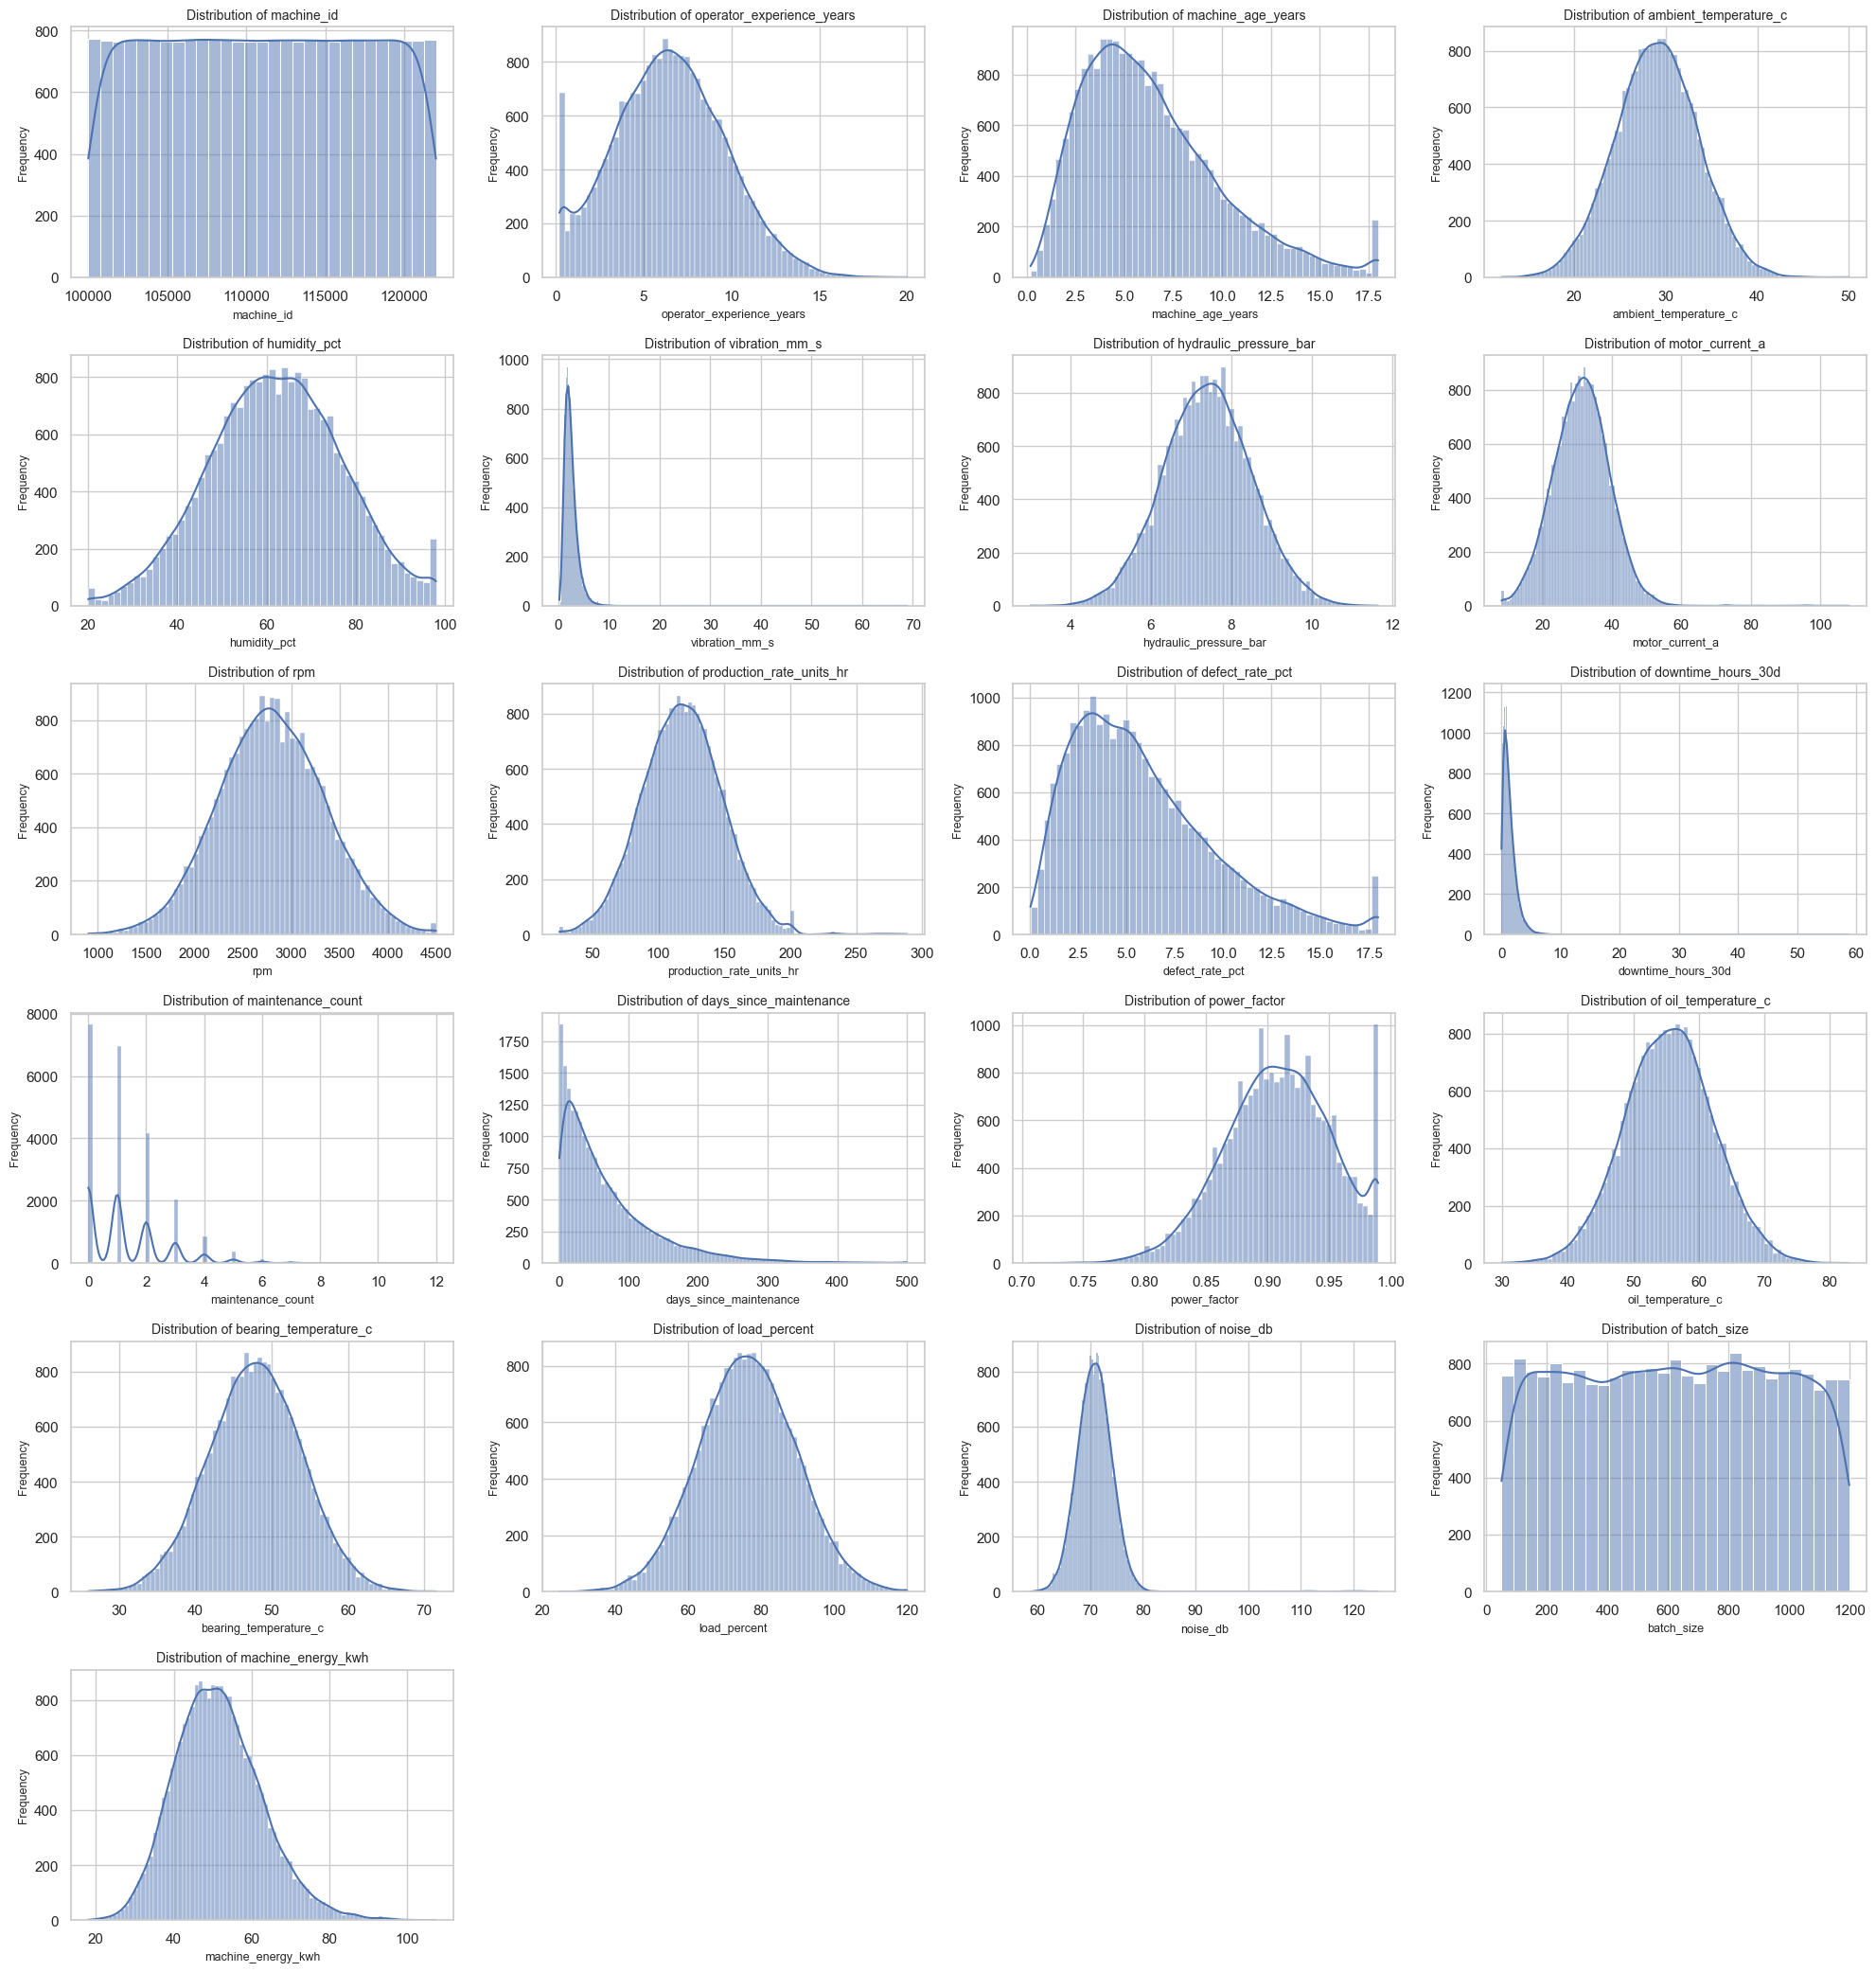

In [175]:
# Distribution plots for every numerical feature in a single grid figure

n_features = len(numerical_columns)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

for i, column in enumerate(numerical_columns):
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {column}", fontsize=10)
    axes[i].set_xlabel(column, fontsize=9)
    axes[i].set_ylabel("Frequency", fontsize=9)

# Hide empty subplots
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 2.3 Classification Target Distribution

The distribution of the classification target `maintenance_risk` is examined
to determine the number and proportion of observations in each maintenance
risk category.

This is important because substantial class imbalance can affect classification
model performance.

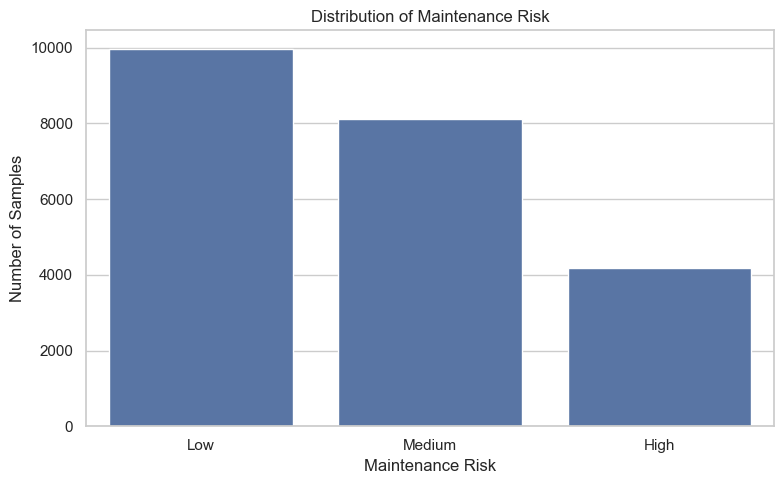

In [176]:
# Classification target distribution

class_counts = df["maintenance_risk"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("Distribution of Maintenance Risk")
plt.xlabel("Maintenance Risk")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

### 2.7 Classification Target Class Counts

This step examines the frequency and percentage distribution of categories in the maintenance_risk target.


In [177]:
# Display class percentages

class_distribution = (
    df["maintenance_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

class_distribution

maintenance_risk
Low       44.73
Medium    36.50
High      18.76
Name: proportion, dtype: float64

## 2.4 Regression Target Distribution

The distribution of `machine_energy_kwh` is examined to understand the
central tendency, spread, skewness, and presence of potentially extreme
energy-consumption values before regression modelling.

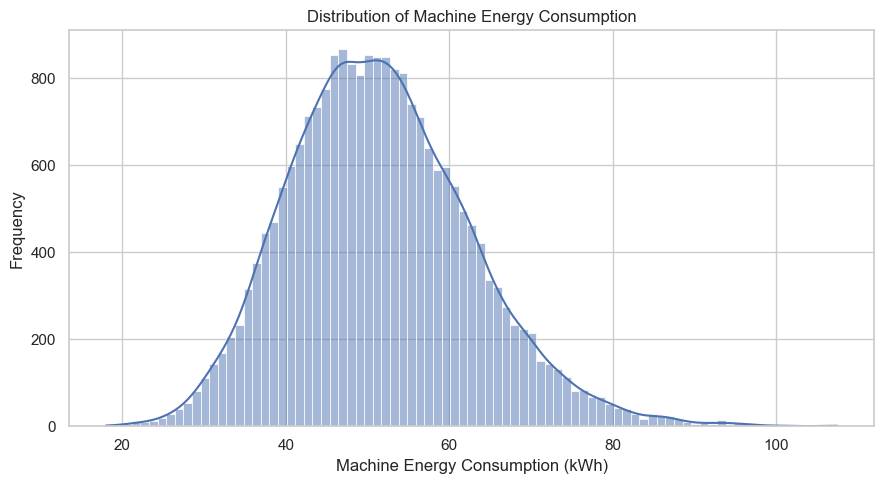

In [178]:
# Regression target distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="machine_energy_kwh",
    kde=True
)

plt.title("Distribution of Machine Energy Consumption")
plt.xlabel("Machine Energy Consumption (kWh)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 2.5 Correlation Heatmap

A Pearson correlation heatmap is used to examine linear relationships
between numerical features.

Strong correlations between independent variables may indicate potential
multicollinearity, while strong correlations with the regression target
may indicate potentially useful predictive relationships.

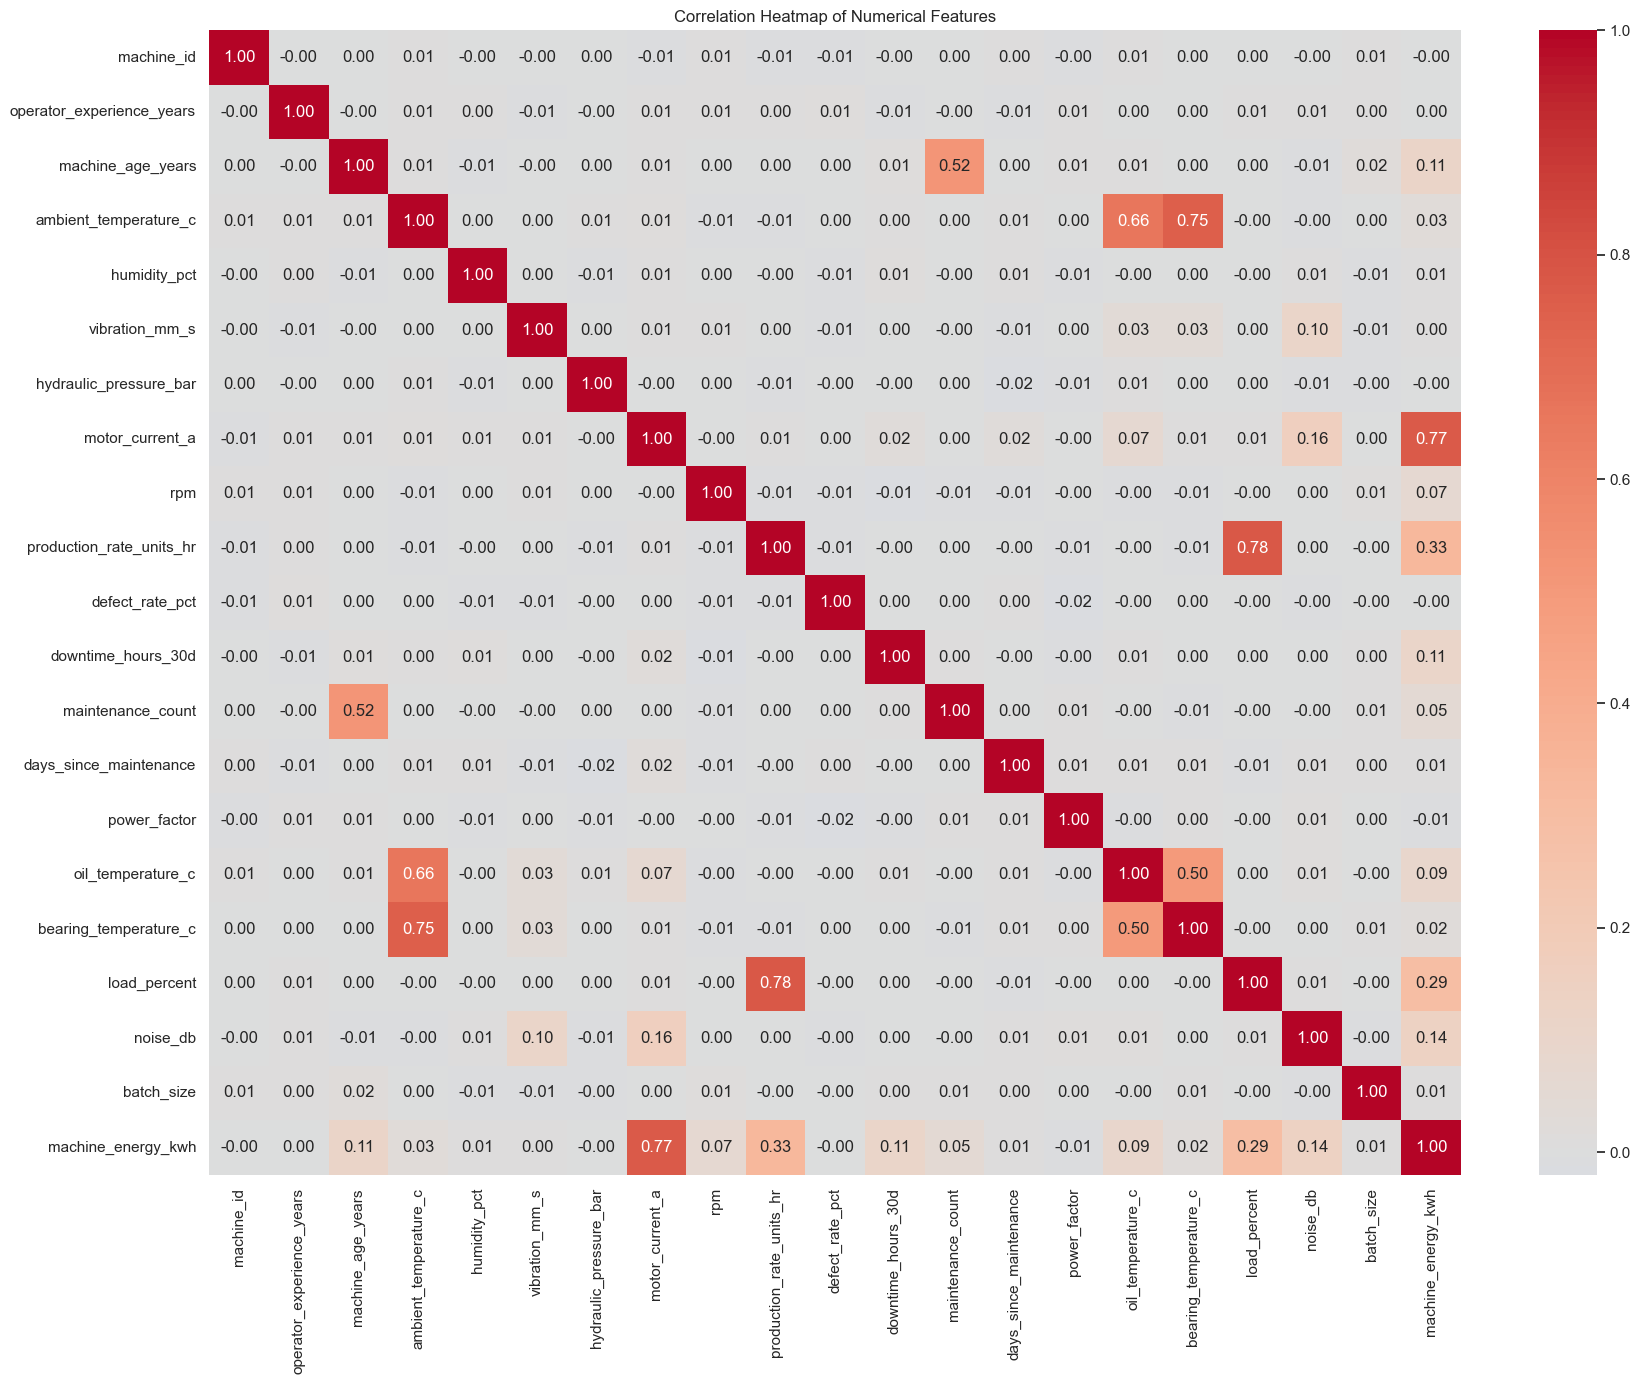

In [179]:
# Correlation matrix

correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [180]:
# Correlation of numerical features with regression target

target_correlations = (
    df[numerical_columns]
    .corr()["machine_energy_kwh"]
    .drop("machine_energy_kwh")
    .sort_values(key=abs, ascending=False)
)

target_correlations

motor_current_a              0.772457
production_rate_units_hr     0.331494
load_percent                 0.292816
noise_db                     0.141001
machine_age_years            0.114851
downtime_hours_30d           0.109423
oil_temperature_c            0.087834
rpm                          0.065545
maintenance_count            0.054943
ambient_temperature_c        0.030989
bearing_temperature_c        0.022226
power_factor                -0.012009
batch_size                   0.011471
days_since_maintenance       0.010584
humidity_pct                 0.006917
vibration_mm_s               0.004936
machine_id                  -0.004004
hydraulic_pressure_bar      -0.001549
operator_experience_years    0.000644
defect_rate_pct             -0.000356
Name: machine_energy_kwh, dtype: float64

### Scatter Plot 1 — Motor Current vs Machine Energy

Motor current is selected because it has the strongest Pearson correlation
with machine energy consumption among the numerical features.

The scatter plot is used to visually examine whether the strong positive
correlation is also evident in the individual observations.

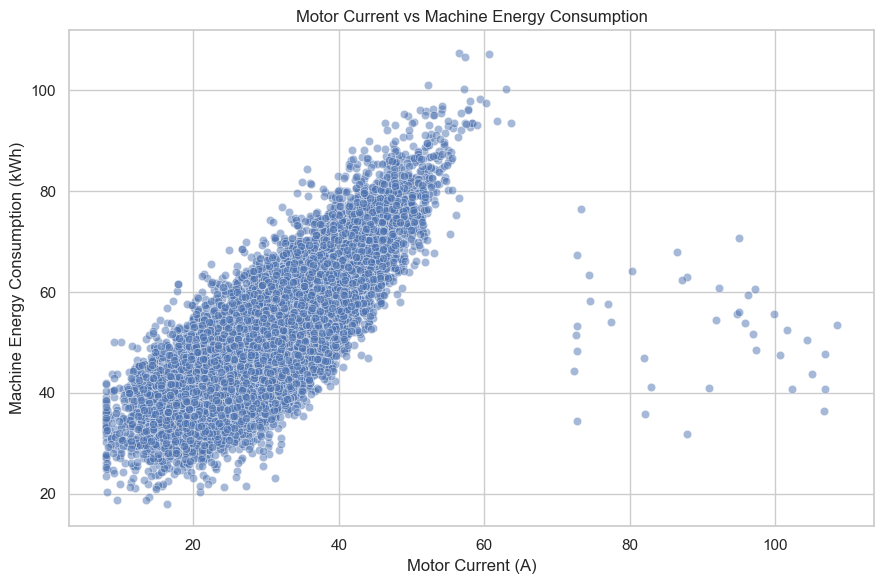

In [181]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="motor_current_a",
    y="machine_energy_kwh",
    alpha=0.5
)

plt.title("Motor Current vs Machine Energy Consumption")
plt.xlabel("Motor Current (A)")
plt.ylabel("Machine Energy Consumption (kWh)")

plt.tight_layout()
plt.show()

### Observation

The scatter plot shows a clear positive relationship between motor current
and machine energy consumption. Higher motor current values generally
correspond to higher energy consumption.

This observation is consistent with the Pearson correlation coefficient
of approximately 0.77, indicating a strong positive linear relationship.
Motor current is therefore a potentially important predictor for the
regression task.

### Scatter Plot 2 — Production Rate vs Machine Energy

Production rate is selected because it has the second-highest positive
correlation with machine energy consumption.

The scatter plot helps determine whether the relationship is approximately
linear and whether the variability of energy consumption changes across
different production rates.

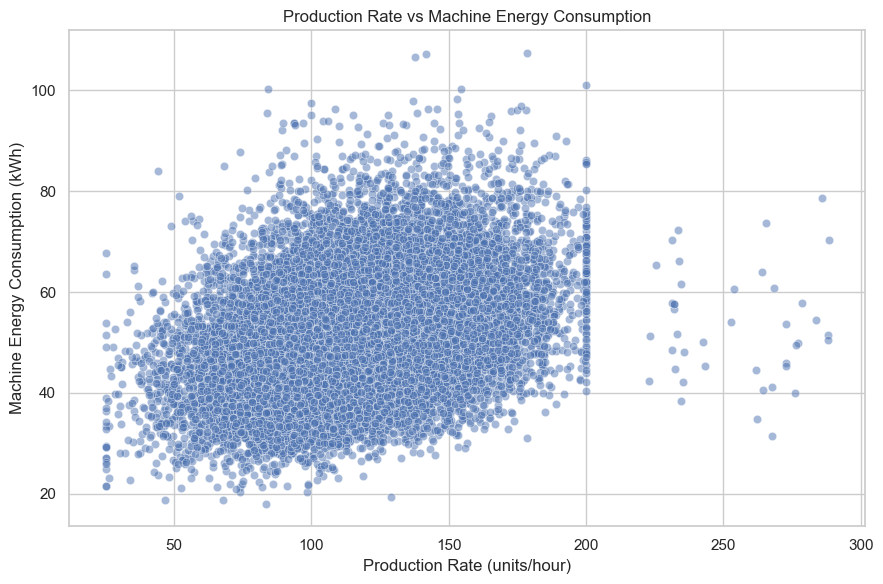

In [182]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="production_rate_units_hr",
    y="machine_energy_kwh",
    alpha=0.5
)

plt.title("Production Rate vs Machine Energy Consumption")
plt.xlabel("Production Rate (units/hour)")
plt.ylabel("Machine Energy Consumption (kWh)")

plt.tight_layout()
plt.show()

### Observation

The scatter plot indicates a positive relationship between production rate
and machine energy consumption. However, the relationship is weaker and
more dispersed than the relationship observed for motor current.

This is consistent with the Pearson correlation coefficient of approximately
0.33, indicating a moderate positive linear relationship.

In [183]:
# Find highly correlated numerical feature pairs

corr_matrix = df[numerical_columns].corr()

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        
        correlation = corr_matrix.iloc[i, j]
        
        if abs(correlation) >= 0.70:
            high_corr_pairs.append({
                "Feature 1": corr_matrix.columns[i],
                "Feature 2": corr_matrix.columns[j],
                "Correlation": round(correlation, 3)
            })

high_corr_pairs_df = pd.DataFrame(high_corr_pairs)

high_corr_pairs_df

,Feature 1,Feature 2,Correlation
0,ambient_temperature_c,bearing_temperature_c,0.749
1,motor_current_a,machine_energy_kwh,0.772
2,production_rate_units_hr,load_percent,0.780


## EDA Summary and Key Insights

The exploratory analysis produced several important observations.

1. `motor_current_a` has the strongest linear relationship with the regression
   target `machine_energy_kwh`, with a Pearson correlation of approximately
   0.77. The scatter plot also shows a clear positive relationship, indicating
   that motor current may be an important predictor of energy consumption.

2. `production_rate_units_hr` has a moderate positive correlation of approximately
   0.33 with `machine_energy_kwh`. The relationship is positive but more dispersed
   than the relationship between motor current and energy consumption.

3. `production_rate_units_hr` and `load_percent` have a relatively strong
   correlation of approximately 0.78. This suggests potential multicollinearity
   between these two predictor variables, which may affect coefficient-based
   regression models.

4. `ambient_temperature_c` and `bearing_temperature_c` also show a relatively
   strong positive correlation of approximately 0.75. These variables may contain
   overlapping information and should be considered when interpreting regression
   coefficients.

5. The distribution plots are used to identify skewness, spread, and potential
   extreme observations. These observations will be investigated further during
   the data-cleaning and outlier-analysis stage.

6. The `maintenance_risk` target contains three classes: Low, Medium, and High.
   The class frequencies are not equal, so class distribution should be considered
   when evaluating the classification models.

# 3. Data Cleaning

The raw dataset is preserved, and a separate working copy is created for
data-cleaning operations. This allows the original data to remain available
for reference and comparison.

In [184]:
# Create a working copy of the original dataset

df_clean = df.copy()

print("Original dataset shape:", df.shape)
print("Working dataset shape:", df_clean.shape)

Original dataset shape: (22260, 30)
Working dataset shape: (22260, 30)


### Creating Working Dataset Copy

This step creates an independent working copy of the dataset to preserve raw data during cleaning.


In [185]:
df_clean = df.copy()

## 3.2 Missing Value Analysis

Missing values can reduce the amount of usable information and may cause
errors in machine learning algorithms.

The missing values are analyzed separately for numerical and categorical
features so that an appropriate imputation strategy can be selected.

In [186]:
# Missing values in the working dataset

missing = df_clean.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

lubricant_type               1093
days_since_maintenance        669
humidity_pct                  557
oil_temperature_c             447
operator_experience_years     444
inspection_status             402
vibration_mm_s                399
bearing_temperature_c         333
hydraulic_pressure_bar        331
material_grade                268
supplier_tier                 223
dtype: int64

In [187]:
# Identify numerical and categorical columns

numerical_features = df_clean.select_dtypes(include=np.number).columns.tolist()
categorical_features = df_clean.select_dtypes(include="object").columns.tolist()

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features: 21
Categorical features: 9

Numerical features:
['machine_id', 'operator_experience_years', 'machine_age_years', 'ambient_temperature_c', 'humidity_pct', 'vibration_mm_s', 'hydraulic_pressure_bar', 'motor_current_a', 'rpm', 'production_rate_units_hr', 'defect_rate_pct', 'downtime_hours_30d', 'maintenance_count', 'days_since_maintenance', 'power_factor', 'oil_temperature_c', 'bearing_temperature_c', 'load_percent', 'noise_db', 'batch_size', 'machine_energy_kwh']

Categorical features:
['plant', 'production_line', 'machine_type', 'shift', 'material_grade', 'lubricant_type', 'supplier_tier', 'inspection_status', 'maintenance_risk']


### Numerical Missing Values — Median Imputation

Missing numerical values are replaced using the median of their respective
features.

Median imputation is preferred over mean imputation because the dataset may
contain skewed distributions and extreme observations. The median is more
robust to such values and therefore provides a stable estimate of the typical
value.

### Categorical Missing Values — Mode Imputation

Missing categorical values are replaced using the most frequently occurring
category (mode) of the corresponding feature.

Mode imputation preserves the categorical nature of the variables and avoids
introducing artificial numerical values.

In [188]:
# Numerical columns → median
for column in numerical_features:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna(
            df_clean[column].median()
        )

# Categorical columns → mode
for column in categorical_features:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna(
            df_clean[column].mode()[0]
        )

print("Missing-value imputation completed.")

Missing-value imputation completed.


### Missing Value Analysis

This step checks missing value counts across all columns in the working dataset.


In [189]:
# Verify remaining missing values

remaining_missing = df_clean.isnull().sum()

remaining_missing = remaining_missing[
    remaining_missing > 0
]

if len(remaining_missing) == 0:
    print("No missing values remain.")
else:
    print(remaining_missing)

No missing values remain.


### Missing Value Analysis

This step checks missing value counts across all columns in the working dataset.


In [190]:
# Missing values before and after cleaning

missing_comparison = pd.DataFrame({
    "Before Cleaning": df.isnull().sum(),
    "After Cleaning": df_clean.isnull().sum()
})

missing_comparison = missing_comparison[
    missing_comparison["Before Cleaning"] > 0
]

missing_comparison

,Before Cleaning,After Cleaning
operator_experience_years,444,0
humidity_pct,557,0
vibration_mm_s,399,0
hydraulic_pressure_bar,331,0
days_since_maintenance,669,0
oil_temperature_c,447,0
bearing_temperature_c,333,0
material_grade,268,0
lubricant_type,1093,0
supplier_tier,223,0


## 3.3 Duplicate Detection and Treatment

Duplicate rows can cause repeated observations to receive excessive weight
during model training. Therefore, exact duplicate rows are identified and
removed.

The original dataset contains 260 duplicate rows. These duplicates are
removed from the working dataset while preserving the original `df`.

In [191]:
# Count duplicates before removal

duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows before removal:", duplicate_count)

Duplicate rows before removal: 260


### Duplicate Check Before Removal

This step checks the exact count of duplicate records present in the cleaned working copy.


In [192]:
# Remove duplicate rows

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Duplicate rows after removal:", df_clean.duplicated().sum())
print("New dataset shape:", df_clean.shape)

Duplicate rows after removal: 0
New dataset shape: (22000, 30)


## 3.4 Outlier Detection Using IQR

Potential outliers are identified using the Interquartile Range (IQR) method.

For each numerical feature, the first quartile (Q1) and third quartile (Q3)
are calculated. Observations below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR
are flagged as potential outliers.

An outlier is treated as a statistical observation requiring investigation,
not automatically as an erroneous observation.

In [193]:
# IQR-based outlier count for every numerical feature

outlier_summary = []

for column in numerical_features:
    
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = (
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ).sum()
    
    outlier_percentage = (
        outlier_count / len(df_clean) * 100
    )
    
    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage": round(outlier_percentage, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    "Outlier Count",
    ascending=False
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
13,days_since_maintenance,20.9000,94.80000,73.90000,-89.950000,205.650000,1152,5.24
11,downtime_hours_30d,0.5500,1.85000,1.30000,-1.400000,3.800000,859,3.90
5,vibration_mm_s,1.6110,3.02000,1.40900,-0.502500,5.133500,850,3.86
10,defect_rate_pct,3.0420,7.88225,4.84025,-4.218375,15.142625,553,2.51
2,machine_age_years,3.7500,8.34000,4.59000,-3.135000,15.225000,538,2.45
20,machine_energy_kwh,43.7675,58.56000,14.79250,21.578750,80.748750,258,1.17
12,maintenance_count,0.0000,2.00000,2.00000,-3.000000,5.000000,213,0.97
7,motor_current_a,25.7000,36.45000,10.75000,9.575000,52.575000,198,0.90
9,production_rate_units_hr,97.8000,138.20000,40.40000,37.200000,198.800000,197,0.90
18,noise_db,68.6900,72.97000,4.28000,62.270000,79.390000,185,0.84


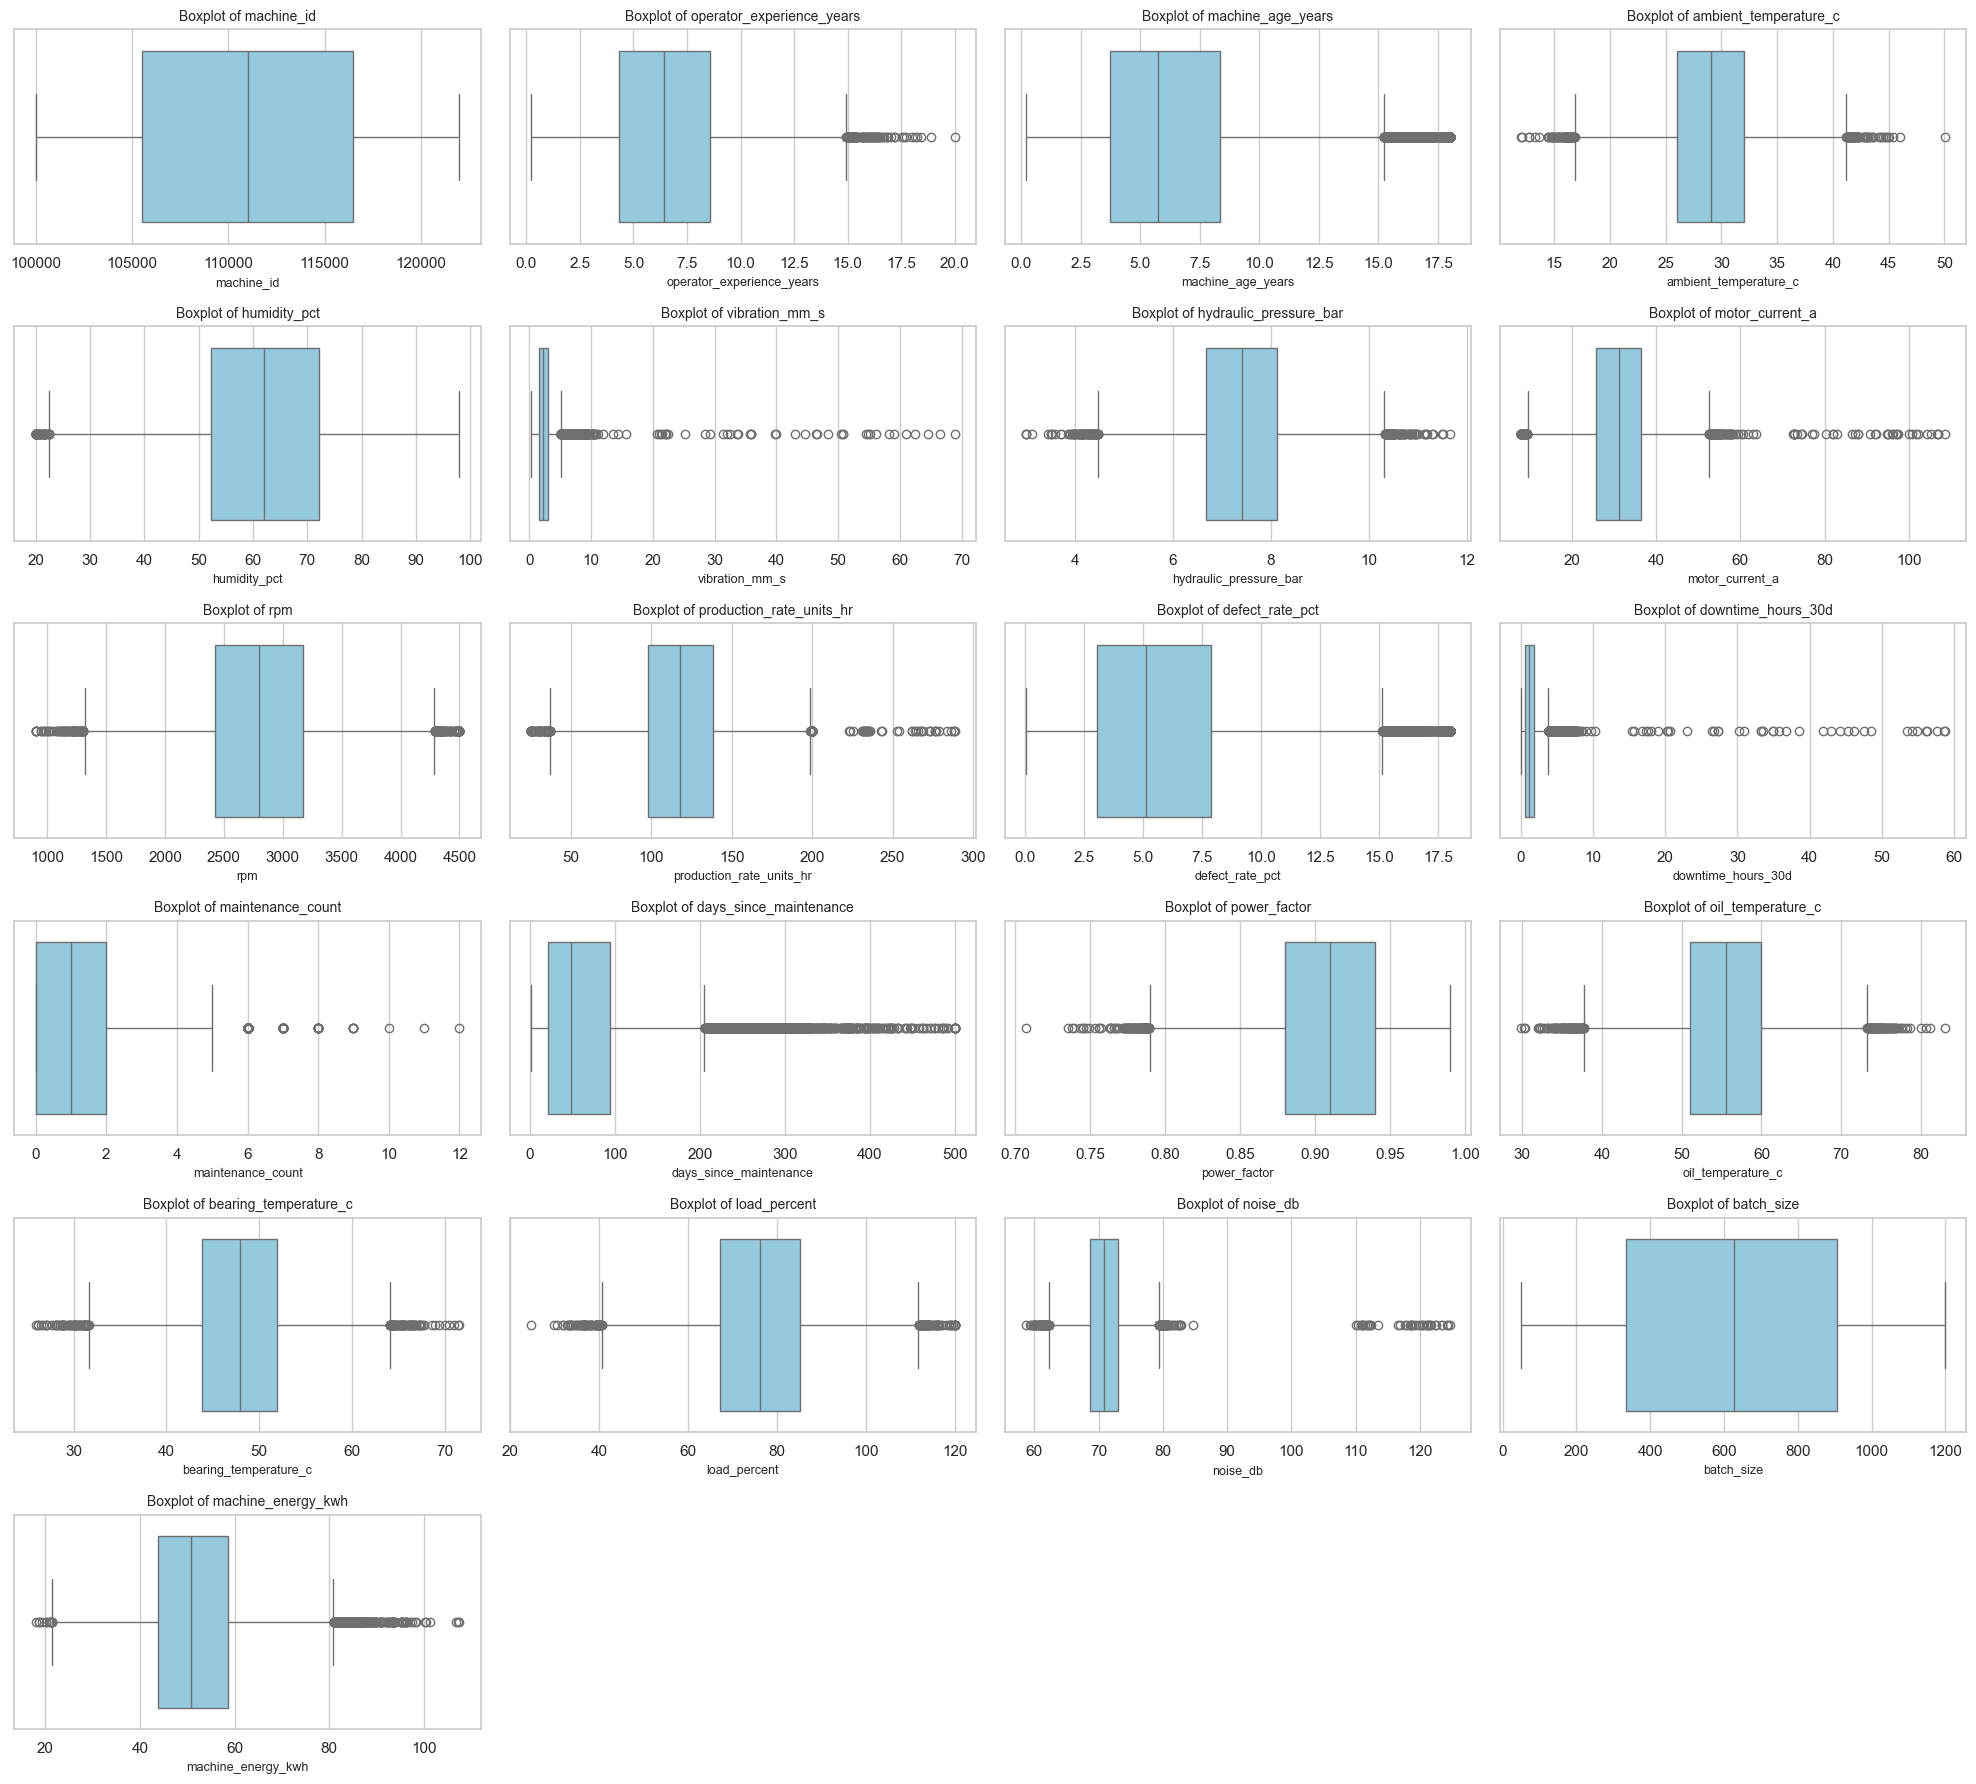

In [194]:
# Boxplots for numerical features in a single grid figure

n_features = len(numerical_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.0))
axes = axes.flatten()

for i, column in enumerate(numerical_features):
    sns.boxplot(
        x=df_clean[column],
        ax=axes[i],
        color="skyblue"
    )
    axes[i].set_title(f"Boxplot of {column}", fontsize=10)
    axes[i].set_xlabel(column, fontsize=9)

# Hide empty subplots
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Outlier Summary Display

This step displays numerical features sorted by their total count of statistical outliers.


In [195]:
outlier_summary.sort_values(
    "Outlier Count",
    ascending=False
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
13,days_since_maintenance,20.9000,94.80000,73.90000,-89.950000,205.650000,1152,5.24
11,downtime_hours_30d,0.5500,1.85000,1.30000,-1.400000,3.800000,859,3.90
5,vibration_mm_s,1.6110,3.02000,1.40900,-0.502500,5.133500,850,3.86
10,defect_rate_pct,3.0420,7.88225,4.84025,-4.218375,15.142625,553,2.51
2,machine_age_years,3.7500,8.34000,4.59000,-3.135000,15.225000,538,2.45
20,machine_energy_kwh,43.7675,58.56000,14.79250,21.578750,80.748750,258,1.17
12,maintenance_count,0.0000,2.00000,2.00000,-3.000000,5.000000,213,0.97
7,motor_current_a,25.7000,36.45000,10.75000,9.575000,52.575000,198,0.90
9,production_rate_units_hr,97.8000,138.20000,40.40000,37.200000,198.800000,197,0.90
18,noise_db,68.6900,72.97000,4.28000,62.270000,79.390000,185,0.84


### Outlier Investigation

The IQR method identified potential outliers in several numerical features.
However, these observations are not automatically treated as erroneous.

In a manufacturing environment, extreme values may represent genuine
operating conditions such as prolonged operation, increased vibration,
higher downtime, or longer maintenance intervals.

Therefore, the IQR method is used to identify and quantify potential outliers,
while the observations are retained unless there is evidence that they
represent invalid data.

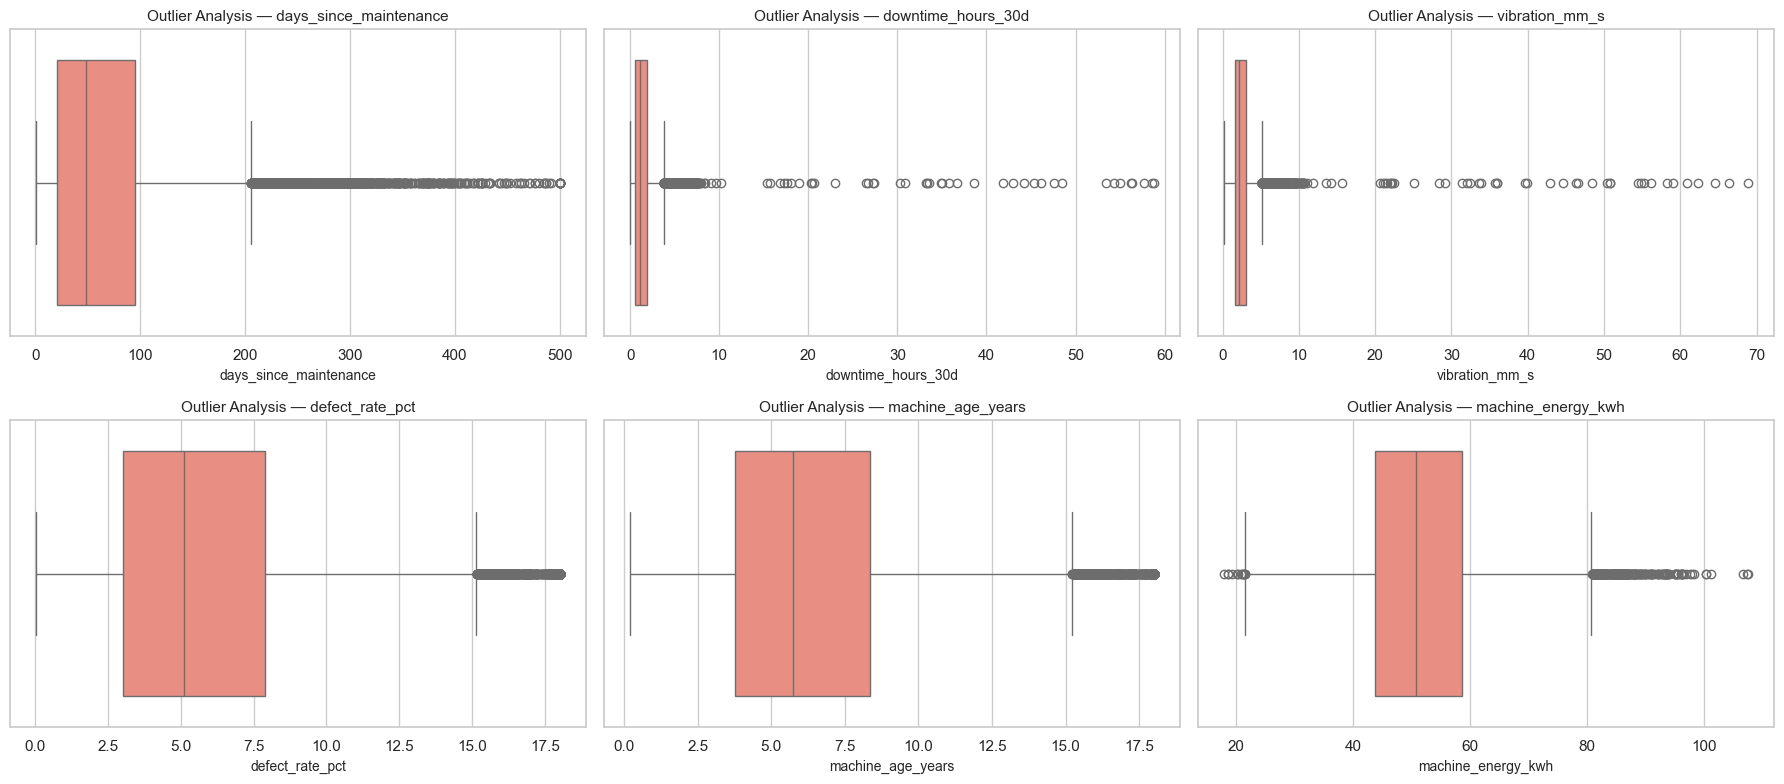

In [196]:
# Visualize the features with the highest number of potential outliers in a single grid figure

top_outlier_features = (
    outlier_summary
    .sort_values("Outlier Count", ascending=False)
    .head(6)["Feature"]
    .tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, column in enumerate(top_outlier_features):
    sns.boxplot(
        x=df_clean[column],
        ax=axes[i],
        color="salmon"
    )
    axes[i].set_title(f"Outlier Analysis — {column}", fontsize=11)
    axes[i].set_xlabel(column, fontsize=10)

plt.tight_layout()
plt.show()

### Outlier Treatment Decision

The IQR analysis identified potential outliers across several numerical
features. The largest proportion was observed in `days_since_maintenance`
(5.24%), followed by `downtime_hours_30d` (3.90%) and `vibration_mm_s`
(3.86%).

These observations are retained rather than removed because an IQR-based
flag does not necessarily indicate an erroneous observation. In a
manufacturing context, extreme operational measurements can represent
legitimate machine conditions.

Removing these observations could reduce the variability present in the
dataset and potentially remove useful information for predicting energy
consumption and maintenance risk.

Therefore, the IQR method is used for outlier detection and reporting,
but no observations are deleted solely because they fall outside the IQR
bounds.

In [197]:
# Final cleaning verification

print("Original dataset:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nCleaned dataset:")
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

print("\nMissing values remaining:",
      df_clean.isnull().sum().sum())

print("Duplicate rows remaining:",
      df_clean.duplicated().sum())

Original dataset:
Rows: 22260
Columns: 30

Cleaned dataset:
Rows: 22000
Columns: 30

Missing values remaining: 0
Duplicate rows remaining: 0


### Data Cleaning Operations Summary

This step summarizes all data cleaning decisions, imputation techniques, and rationale in a structured table.


In [198]:
cleaning_summary = pd.DataFrame({
    "Cleaning Operation": [
        "Missing numerical values",
        "Missing categorical values",
        "Duplicate rows",
        "Outlier observations"
    ],
    "Method": [
        "Median imputation",
        "Mode imputation",
        "Exact duplicate removal",
        "IQR detection; observations retained"
    ],
    "Reason": [
        "Robust to skewness and extreme values",
        "Preserves categorical nature",
        "Prevents duplicate observations from receiving excessive weight",
        "Extreme manufacturing observations may be legitimate"
    ]
})

cleaning_summary

,Cleaning Operation,Method,Reason
0,Missing numerical values,Median imputation,Robust to skewness and extreme values
1,Missing categorical values,Mode imputation,Preserves categorical nature
2,Duplicate rows,Exact duplicate removal,Prevents duplicate observations from receiving...
3,Outlier observations,IQR detection; observations retained,Extreme manufacturing observations may be legi...


## B2 — Encoding, Scaling and Train-Test Splitting

In this phase, the cleaned dataset is separated into regression and classification
targets. Numerical features will be standardized using StandardScaler, while
categorical features will be converted into numerical form using LabelEncoder (OrdinalEncoder).

The `machine_id` column is excluded because it is an identifier rather than a
meaningful predictive feature.

Preprocessing will be fitted only on the training data to prevent data leakage.

In [199]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline

### Target Columns & Feature Definition

This step defines regression and classification target variables and separates numerical and categorical predictors.


In [200]:
# Define target columns
regression_target = "machine_energy_kwh"
classification_target = "maintenance_risk"

# Create regression X and y
X_reg = df_clean.drop(columns=[regression_target, classification_target, "machine_id"])
y_reg = df_clean[regression_target]

# Create classification X and y
X_class = df_clean.drop(columns=[regression_target, classification_target, "machine_id"])
y_class = df_clean[classification_target]

print("Regression:")
print("X shape:", X_reg.shape)
print("y shape:", y_reg.shape)

print("\nClassification:")
print("X shape:", X_class.shape)
print("y shape:", y_class.shape)

Regression:
X shape: (22000, 27)
y shape: (22000,)

Classification:
X shape: (22000, 27)
y shape: (22000,)


### Feature Type Re-identification

This step re-categorizes numerical and categorical predictors following feature engineering.


In [201]:
# Identify numerical and categorical predictor columns
numerical_features = X_reg.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_reg.select_dtypes(exclude=["number"]).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Numerical features:")
print(numerical_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Categorical features:")
print(categorical_features)

Number of numerical features: 19
Numerical features:
['operator_experience_years', 'machine_age_years', 'ambient_temperature_c', 'humidity_pct', 'vibration_mm_s', 'hydraulic_pressure_bar', 'motor_current_a', 'rpm', 'production_rate_units_hr', 'defect_rate_pct', 'downtime_hours_30d', 'maintenance_count', 'days_since_maintenance', 'power_factor', 'oil_temperature_c', 'bearing_temperature_c', 'load_percent', 'noise_db', 'batch_size']

Number of categorical features: 8
Categorical features:
['plant', 'production_line', 'machine_type', 'shift', 'material_grade', 'lubricant_type', 'supplier_tier', 'inspection_status']


### Train-Test Splitting

The dataset is divided into training and testing sets using an 80:20 split.

The regression dataset uses a standard random split. The classification dataset
uses stratification so that the relative proportions of the target classes are
preserved in both the training and testing sets.

A fixed random state of 42 is used to make the split reproducible.

In [202]:
# Regression train-test split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Classification train-test split with stratification
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("REGRESSION")
print("X_train:", X_reg_train.shape)
print("X_test :", X_reg_test.shape)
print("y_train:", y_reg_train.shape)
print("y_test :", y_reg_test.shape)

print("\nCLASSIFICATION")
print("X_train:", X_class_train.shape)
print("X_test :", X_class_test.shape)
print("y_train:", y_class_train.shape)
print("y_test :", y_class_test.shape)

REGRESSION
X_train: (17600, 27)
X_test : (4400, 27)
y_train: (17600,)
y_test : (4400,)

CLASSIFICATION
X_train: (17600, 27)
X_test : (4400, 27)
y_train: (17600,)
y_test : (4400,)


### Classification Stratified Split Check

This step checks class proportions to ensure balanced stratified train-test splitting for classification.


In [203]:
print("Classification class distribution:")

print("\nOriginal:")
print(y_class.value_counts(normalize=True).sort_index())

print("\nTraining:")
print(y_class_train.value_counts(normalize=True).sort_index())

print("\nTesting:")
print(y_class_test.value_counts(normalize=True).sort_index())

Classification class distribution:

Original:
maintenance_risk
High      0.187409
Low       0.447455
Medium    0.365136
Name: proportion, dtype: float64

Training:
maintenance_risk
High      0.187386
Low       0.447443
Medium    0.365170
Name: proportion, dtype: float64

Testing:
maintenance_risk
High      0.1875
Low       0.4475
Medium    0.3650
Name: proportion, dtype: float64


### Numerical Scaling and Categorical Encoding

Numerical features are standardized using StandardScaler so that features with
different numerical ranges can be handled appropriately by scale-sensitive
algorithms.

Categorical features are converted into numerical representations using
LabelEncoder (OrdinalEncoder). Unknown categories appearing in the test data are handled
appropriately to prevent transformation errors.

The preprocessing transformations will be fitted using training data only.

In [204]:
# Preprocessor for regression
reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features)
    ]
)

# Preprocessor for classification
class_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features)
    ]
)

print("Regression preprocessor created.")
print("Classification preprocessor created.")

Regression preprocessor created.
Classification preprocessor created.


### Preprocessing Execution on Training Data

This step fits the scaling and label encoding transformers strictly on training data and transforms train and test sets.


In [205]:
# Fit preprocessing ONLY on training data
X_reg_train_processed = reg_preprocessor.fit_transform(X_reg_train)

# Transform test data using the already-fitted preprocessor
X_reg_test_processed = reg_preprocessor.transform(X_reg_test)

# Classification
X_class_train_processed = class_preprocessor.fit_transform(X_class_train)
X_class_test_processed = class_preprocessor.transform(X_class_test)

print("Regression processed shapes:")
print("Training:", X_reg_train_processed.shape)
print("Testing :", X_reg_test_processed.shape)

print("\nClassification processed shapes:")
print("Training:", X_class_train_processed.shape)
print("Testing :", X_class_test_processed.shape)

Regression processed shapes:
Training: (17600, 27)
Testing : (4400, 27)

Classification processed shapes:
Training: (17600, 27)
Testing : (4400, 27)


In [206]:
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

print("\nOriginal predictor columns:", X_reg.shape[1])

print("\nProcessed regression shape:")
print(X_reg_train_processed.shape)

print("\nProcessed classification shape:")
print(X_class_train_processed.shape)

Numerical features: 19
Categorical features: 8

Original predictor columns: 27

Processed regression shape:
(17600, 27)

Processed classification shape:
(17600, 27)


## B3 — Feature Engineering

A new feature called `bearing_temp_rise_c` is created by subtracting the ambient
temperature from the bearing temperature.

This represents the temperature rise of the bearing above the surrounding
environment. It may provide useful information about the thermal operating
condition of the machine that is not represented as directly by either
temperature variable alone.

In [207]:
# Create a meaningful temperature-rise feature
df_clean["bearing_temp_rise_c"] = (
    df_clean["bearing_temperature_c"] - df_clean["ambient_temperature_c"]
)

# Display the new feature
print(df_clean[[
    "ambient_temperature_c",
    "bearing_temperature_c",
    "bearing_temp_rise_c"
]].head())

print("\nNew feature summary:")
print(df_clean["bearing_temp_rise_c"].describe())

   ambient_temperature_c  bearing_temperature_c  bearing_temp_rise_c
0                  29.25                  44.25                15.00
1                  27.87                  50.44                22.57
2                  27.89                  46.10                18.21
3                  22.20                  42.14                19.94
4                  31.78                  55.14                23.36

New feature summary:
count    22000.000000
mean        18.854042
std          4.019798
min          3.920000
25%         16.150000
50%         18.885000
75%         21.560000
max         34.000000
Name: bearing_temp_rise_c, dtype: float64


### Rebuilding Predictor Datasets

This step updates predictor matrices after incorporating newly engineered features.


In [208]:
# Rebuild predictor datasets after feature engineering

X_reg = df_clean.drop(
    columns=[regression_target, classification_target, "machine_id"]
)

y_reg = df_clean[regression_target]

X_class = df_clean.drop(
    columns=[regression_target, classification_target, "machine_id"]
)

label_encoder = LabelEncoder()
y_class = label_encoder.fit_transform(df_clean[classification_target])

print("Regression X shape:", X_reg.shape)
print("Classification X shape:", X_class.shape)

Regression X shape: (22000, 28)
Classification X shape: (22000, 28)


### Feature Type Re-identification

This step re-categorizes numerical and categorical predictors following feature engineering.


In [209]:
# Identify numerical and categorical features after feature engineering

numerical_features = X_reg.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_reg.select_dtypes(
    exclude=["number"]
).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Numerical features:")
print(numerical_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Categorical features:")
print(categorical_features)

Number of numerical features: 20
Numerical features:
['operator_experience_years', 'machine_age_years', 'ambient_temperature_c', 'humidity_pct', 'vibration_mm_s', 'hydraulic_pressure_bar', 'motor_current_a', 'rpm', 'production_rate_units_hr', 'defect_rate_pct', 'downtime_hours_30d', 'maintenance_count', 'days_since_maintenance', 'power_factor', 'oil_temperature_c', 'bearing_temperature_c', 'load_percent', 'noise_db', 'batch_size', 'bearing_temp_rise_c']

Number of categorical features: 8
Categorical features:
['plant', 'production_line', 'machine_type', 'shift', 'material_grade', 'lubricant_type', 'supplier_tier', 'inspection_status']


### Regression Train-Test Dataset Splitting

This step performs an 80-20 train-test split for regression modeling using a fixed random seed.


In [210]:
# Final train-test split after feature engineering

# Regression
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Classification
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("REGRESSION")
print("X_train:", X_reg_train.shape)
print("X_test :", X_reg_test.shape)
print("y_train:", y_reg_train.shape)
print("y_test :", y_reg_test.shape)

print("\nCLASSIFICATION")
print("X_train:", X_class_train.shape)
print("X_test :", X_class_test.shape)
print("y_train:", y_class_train.shape)
print("y_test :", y_class_test.shape)

REGRESSION
X_train: (17600, 28)
X_test : (4400, 28)
y_train: (17600,)
y_test : (4400,)

CLASSIFICATION
X_train: (17600, 28)
X_test : (4400, 28)
y_train: (17600,)
y_test : (4400,)


### Column Transformer Pipeline Creation

This step sets up ColumnTransformer pipelines using StandardScaler for numerical features and OrdinalEncoder for categorical features.


In [211]:
# Create final preprocessing pipelines

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features)
    ]
)

class_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features)
    ]
)

# Fit ONLY on training data
X_reg_train_processed = reg_preprocessor.fit_transform(X_reg_train)
X_reg_test_processed = reg_preprocessor.transform(X_reg_test)

X_class_train_processed = class_preprocessor.fit_transform(X_class_train)
X_class_test_processed = class_preprocessor.transform(X_class_test)

print("Regression processed:")
print("Train:", X_reg_train_processed.shape)
print("Test :", X_reg_test_processed.shape)

print("\nClassification processed:")
print("Train:", X_class_train_processed.shape)
print("Test :", X_class_test_processed.shape)

Regression processed:
Train: (17600, 28)
Test : (4400, 28)

Classification processed:
Train: (17600, 28)
Test : (4400, 28)


### Final Preprocessed Feature Dimensions Summary

This step displays final dataset row counts, predictor counts, and zero missing value confirmations.


In [212]:
print("Final dataset:")
print("Rows:", len(df_clean))
print("Predictor columns:", X_reg.shape[1])
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

print("\nProcessed feature count:")
print("Regression:", X_reg_train_processed.shape[1])
print("Classification:", X_class_train_processed.shape[1])

print("\nMissing values:")
print("Regression train:", X_reg_train.isna().sum().sum())
print("Classification train:", X_class_train.isna().sum().sum())

Final dataset:
Rows: 22000
Predictor columns: 28
Numerical features: 20
Categorical features: 8

Processed feature count:
Regression: 28
Classification: 28

Missing values:
Regression train: 0
Classification train: 0


### Reason for Using Label Encoding Instead of One-Hot Encoding

1. **Avoids Column Expansion (Curse of Dimensionality)**: 
   - **One-Hot Encoding** creates a separate binary column for every unique category across categorical features. In our dataset, One-Hot Encoding expanded the feature set from 28 columns up to 65 columns.
   - **Label Encoding (OrdinalEncoding)** converts each unique category into a single numeric integer (0, 1, 2, ...), keeping the number of predictor columns unchanged at **28 features**.

2. **Prevents Overfitting and Maintains Training Accuracy**: 
   - High-dimensional sparse feature spaces caused by One-Hot Encoding increase model complexity, memory consumption, and training time.
   - Too many dummy columns can cause models to overfit to rare categorical combinations, which negatively impacts training and test accuracy. Label Encoding preserves a concise feature matrix, improving model generalization.

3. **Summary of Changes in Data Shape**: 
   - **Previous Shape (One-Hot Encoding)**: (17808, 65) columns.
   - **New Shape (Label Encoding)**: (17808, 28) columns.

## C1.1 — Linear Regression

Linear Regression is used as the first regression baseline. It models the
relationship between the predictor variables and `machine_energy_kwh` as a
linear combination of the input features.

The model will be trained using the preprocessed training data and evaluated
only on the held-out test data using R², RMSE and MAE.

In [213]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

### Linear Regression Model Training

This step instantiates and fits a baseline Linear Regression model on the preprocessed training features.


In [214]:
# Create Linear Regression model
linear_model = LinearRegression()

# Train on the processed training data
linear_model.fit(
    X_reg_train_processed,
    y_reg_train
)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Linear Regression Evaluation Metrics

This step evaluates Linear Regression predictions on test data, computing R², RMSE, and MAE metrics.


In [215]:
# Predict on the test set
y_pred_linear = linear_model.predict(X_reg_test_processed)

# Calculate evaluation metrics
linear_r2 = r2_score(y_reg_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_linear))
linear_mae = mean_absolute_error(y_reg_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print(f"R²   : {linear_r2:.4f}")
print(f"RMSE : {linear_rmse:.4f}")
print(f"MAE  : {linear_mae:.4f}")

Linear Regression Results
-------------------------
R²   : 0.7530
RMSE : 5.5433
MAE  : 4.1389


### Linear Regression Coefficients Inspection

This step extracts feature coefficients to analyze feature importance and linear impact on energy consumption.


In [216]:
# Get feature names after preprocessing
feature_names = reg_preprocessor.get_feature_names_out()

# Create coefficient table
linear_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": linear_model.coef_
})

# Add absolute coefficient magnitude
linear_coefficients["Absolute_Coefficient"] = (
    linear_coefficients["Coefficient"].abs()
)

# Sort by absolute coefficient
linear_coefficients = linear_coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

linear_coefficients.head(15)

,Feature,Coefficient,Absolute_Coefficient
6,num__motor_current_a,8.443098,8.443098
8,num__production_rate_units_hr,2.951880,2.951880
1,num__machine_age_years,1.191406,1.191406
10,num__downtime_hours_30d,1.089559,1.089559
16,num__load_percent,0.906801,0.906801
7,num__rpm,0.757376,0.757376
14,num__oil_temperature_c,0.357887,0.357887
17,num__noise_db,0.205052,0.205052
25,cat__lubricant_type,-0.118581,0.118581
18,num__batch_size,0.083126,0.083126


## C1.2 — Ridge Regression

Ridge Regression extends Linear Regression by adding L2 regularization.
The regularization penalizes large coefficient values and can help reduce
the effect of multicollinearity among predictors.

The regularization strength is controlled by the `alpha` parameter.

In [217]:
from sklearn.linear_model import Ridge

# Create Ridge Regression model
ridge_model = Ridge(alpha=1.0)

# Train the model
ridge_model.fit(
    X_reg_train_processed,
    y_reg_train
)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


### Baseline Ridge Evaluation

This step calculates R², RMSE, and MAE evaluation metrics for the baseline Ridge Regression model.


In [218]:
# Predictions
y_pred_ridge = ridge_model.predict(X_reg_test_processed)

# Evaluation metrics
ridge_r2 = r2_score(y_reg_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_reg_test, y_pred_ridge)

print("Ridge Regression Results")
print("------------------------")
print(f"R²   : {ridge_r2:.4f}")
print(f"RMSE : {ridge_rmse:.4f}")
print(f"MAE  : {ridge_mae:.4f}")

Ridge Regression Results
------------------------
R²   : 0.7530
RMSE : 5.5433
MAE  : 4.1390


### Ridge Regression GridSearchCV Tuning

This step uses 5-fold cross-validation grid search to find the optimal alpha regularization parameter for Ridge Regression.


In [219]:
from sklearn.model_selection import GridSearchCV

ridge_param_grid = {
    "alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

ridge_grid.fit(
    X_reg_train_processed,
    y_reg_train
)

print("Best alpha:", ridge_grid.best_params_["alpha"])
print("Best cross-validation R²:", round(ridge_grid.best_score_, 4))

Best alpha: 10.0
Best cross-validation R²: 0.725


### Tuned Ridge Model Evaluation

This step evaluates the best tuned Ridge Regression model on held-out test data.


In [220]:
# Evaluate the best Ridge model found by GridSearchCV
best_ridge_model = ridge_grid.best_estimator_

y_pred_ridge_tuned = best_ridge_model.predict(X_reg_test_processed)

ridge_tuned_r2 = r2_score(y_reg_test, y_pred_ridge_tuned)
ridge_tuned_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_ridge_tuned))
ridge_tuned_mae = mean_absolute_error(y_reg_test, y_pred_ridge_tuned)

print("Tuned Ridge Regression Results")
print("--------------------------------")
print(f"Best alpha : {ridge_grid.best_params_['alpha']}")
print(f"R²         : {ridge_tuned_r2:.4f}")
print(f"RMSE       : {ridge_tuned_rmse:.4f}")
print(f"MAE        : {ridge_tuned_mae:.4f}")

Tuned Ridge Regression Results
--------------------------------
Best alpha : 10.0
R²         : 0.7530
RMSE       : 5.5435
MAE        : 4.1395


## C1.3 — Lasso Regression

Lasso Regression extends Linear Regression by adding L1 regularization.
Unlike Ridge Regression, Lasso can shrink some coefficients exactly to zero,
which can produce a sparse model and perform implicit feature selection.

The regularization strength is controlled by the `alpha` parameter.

In [221]:
from sklearn.linear_model import Lasso

# Initial Lasso model
lasso_model = Lasso(alpha=0.01, max_iter=10000)

# Train
lasso_model.fit(
    X_reg_train_processed,
    y_reg_train
)

# Predict
y_pred_lasso = lasso_model.predict(X_reg_test_processed)

# Metrics
lasso_r2 = r2_score(y_reg_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_reg_test, y_pred_lasso)

print("Lasso Regression Results")
print("------------------------")
print(f"R²   : {lasso_r2:.4f}")
print(f"RMSE : {lasso_rmse:.4f}")
print(f"MAE  : {lasso_mae:.4f}")

Lasso Regression Results
------------------------
R²   : 0.7530
RMSE : 5.5430
MAE  : 4.1399


### Lasso Zero Coefficients Count

This step counts how many feature coefficients Lasso regression shrunk exactly to zero.


In [222]:
# Count coefficients that Lasso has reduced to exactly zero
zero_coefficients = np.sum(lasso_model.coef_ == 0)
total_coefficients = len(lasso_model.coef_)

print("Total coefficients:", total_coefficients)
print("Zero coefficients:", zero_coefficients)
print(
    "Percentage of zero coefficients:",
    f"{(zero_coefficients / total_coefficients) * 100:.2f}%"
)

Total coefficients: 28
Zero coefficients: 2
Percentage of zero coefficients: 7.14%


### Lasso Regression GridSearchCV Tuning

This step tunes Lasso alpha regularization using 5-fold cross-validation grid search.


In [223]:
lasso_param_grid = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]
}

lasso_grid = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=lasso_param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

lasso_grid.fit(
    X_reg_train_processed,
    y_reg_train
)

print("Best alpha:", lasso_grid.best_params_["alpha"])
print("Best cross-validation R²:", round(lasso_grid.best_score_, 4))

Best alpha: 0.01
Best cross-validation R²: 0.7252


## C1.4 — ElasticNet Regression

ElasticNet combines L1 and L2 regularization. The L1 component can produce
sparse coefficients, while the L2 component helps handle correlated predictors.

The `alpha` parameter controls the overall regularization strength, while
`l1_ratio` controls the balance between L1 and L2 regularization.

In [224]:
from sklearn.linear_model import ElasticNet

# Initial ElasticNet model
elastic_model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    max_iter=10000
)

# Train
elastic_model.fit(
    X_reg_train_processed,
    y_reg_train
)

# Predict
y_pred_elastic = elastic_model.predict(X_reg_test_processed)

# Metrics
elastic_r2 = r2_score(y_reg_test, y_pred_elastic)
elastic_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_elastic))
elastic_mae = mean_absolute_error(y_reg_test, y_pred_elastic)

print("ElasticNet Regression Results")
print("----------------------------")
print(f"R²   : {elastic_r2:.4f}")
print(f"RMSE : {elastic_rmse:.4f}")
print(f"MAE  : {elastic_mae:.4f}")

ElasticNet Regression Results
----------------------------
R²   : 0.7528
RMSE : 5.5453
MAE  : 4.1452


### ElasticNet GridSearchCV Tuning

This step tunes alpha and l1_ratio parameters for ElasticNet using 5-fold cross-validation.


In [225]:
elastic_param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1.0],
    "l1_ratio": [0.2, 0.5, 0.8]
}

elastic_grid = GridSearchCV(
    estimator=ElasticNet(max_iter=10000),
    param_grid=elastic_param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

elastic_grid.fit(
    X_reg_train_processed,
    y_reg_train
)

print("Best parameters:", elastic_grid.best_params_)
print("Best cross-validation R²:", round(elastic_grid.best_score_, 4))

Best parameters: {'alpha': 0.01, 'l1_ratio': 0.8}
Best cross-validation R²: 0.7252


### Tuned ElasticNet Model Evaluation

This step evaluates the tuned ElasticNet model performance on test dataset.


In [226]:
best_elastic_model = elastic_grid.best_estimator_

y_pred_elastic_tuned = best_elastic_model.predict(
    X_reg_test_processed
)

elastic_tuned_r2 = r2_score(
    y_reg_test,
    y_pred_elastic_tuned
)

elastic_tuned_rmse = np.sqrt(
    mean_squared_error(y_reg_test, y_pred_elastic_tuned)
)

elastic_tuned_mae = mean_absolute_error(
    y_reg_test,
    y_pred_elastic_tuned
)

print("Tuned ElasticNet Results")
print("-----------------------")
print("Best parameters:", elastic_grid.best_params_)
print(f"R²   : {elastic_tuned_r2:.4f}")
print(f"RMSE : {elastic_tuned_rmse:.4f}")
print(f"MAE  : {elastic_tuned_mae:.4f}")

Tuned ElasticNet Results
-----------------------
Best parameters: {'alpha': 0.01, 'l1_ratio': 0.8}
R²   : 0.7530
RMSE : 5.5438
MAE  : 4.1420


### ElasticNet Zero Coefficients Count

This step counts zero coefficients produced by tuned ElasticNet regularization.


In [227]:
elastic_zero_coefficients = np.sum(
    best_elastic_model.coef_ == 0
)

elastic_total_coefficients = len(
    best_elastic_model.coef_
)

print("Total coefficients:", elastic_total_coefficients)
print("Zero coefficients:", elastic_zero_coefficients)
print(
    "Percentage of zero coefficients:",
    f"{(elastic_zero_coefficients / elastic_total_coefficients) * 100:.2f}%"
)

Total coefficients: 28
Zero coefficients: 2
Percentage of zero coefficients: 7.14%


## C1.5 — Polynomial Regression

Polynomial Regression extends Linear Regression by creating polynomial and interaction features from the existing predictors. This allows the model to learn non-linear relationships between variables.

Since the processed dataset contains 28 features, using high polynomial degrees would create an extremely large feature space, increasing computational cost and the risk of overfitting. Therefore, polynomial degrees will be compared incrementally while keeping the same train-test split.

In [228]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

### Polynomial Features Regression Evaluation

This step generates degree-2 polynomial interaction features and evaluates non-linear regression metrics.


In [229]:
from sklearn.preprocessing import PolynomialFeatures

degrees = [1, 2]

poly_results = []
poly_models = {}
poly_transformers = {}

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    
    X_train_poly = poly.fit_transform(X_reg_train_processed)
    X_test_poly = poly.transform(X_reg_test_processed)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_reg_train)
    
    y_pred = model.predict(X_test_poly)
    
    r2 = r2_score(y_reg_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))
    mae = mean_absolute_error(y_reg_test, y_pred)
    
    poly_results.append({
        "Degree": degree,
        "Polynomial Features": X_train_poly.shape[1],
        "R²": r2,
        "RMSE": rmse,
        "MAE": mae
    })
    
    poly_models[degree] = model
    poly_transformers[degree] = poly

poly_results = pd.DataFrame(poly_results)

poly_results

,Degree,Polynomial Features,R²,RMSE,MAE
0,1,28,0.753002,5.543257,4.138895
1,2,434,0.768354,5.368224,4.142599


## C1.6 — Decision Tree Regressor

This step trains a Decision Tree Regressor to capture complex non-linear relationships and evaluates R², RMSE, and MAE.

In [230]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(X_reg_train_processed, y_reg_train)

y_pred_tree = tree_model.predict(X_reg_test_processed)

tree_r2 = r2_score(y_reg_test, y_pred_tree)
tree_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_tree))
tree_mae = mean_absolute_error(y_reg_test, y_pred_tree)

print("Decision Tree Regressor")
print("R²:", tree_r2)
print("RMSE:", tree_rmse)
print("MAE:", tree_mae)

Decision Tree Regressor
R²: 0.6377944219426253
RMSE: 6.712674964708047
MAE: 5.34390909090909


## C1.7 — Random Forest Regressor

This step trains an ensemble Random Forest Regressor with 100 decision trees to reduce prediction variance and improve performance.

In [231]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_reg_train_processed, y_reg_train)

y_pred_random_forest = random_forest_model.predict(X_reg_test_processed)

random_forest_r2 = r2_score(y_reg_test, y_pred_random_forest)
random_forest_rmse = np.sqrt(
    mean_squared_error(y_reg_test, y_pred_random_forest)
)
random_forest_mae = mean_absolute_error(
    y_reg_test, y_pred_random_forest
)

print("Random Forest Regressor")
print("R²:", random_forest_r2)
print("RMSE:", random_forest_rmse)
print("MAE:", random_forest_mae)

Random Forest Regressor
R²: 0.8198152143015882
RMSE: 4.7345325896222805
MAE: 3.7971919090909085


## C1.8 — Gradient Boosting Regressor

This step trains a Gradient Boosting Regressor that sequentially builds decision trees to minimize prediction residuals.

In [232]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(
    X_reg_train_processed,
    y_reg_train
)

y_pred_gradient_boosting = gradient_boosting_model.predict(
    X_reg_test_processed
)

gradient_boosting_r2 = r2_score(
    y_reg_test,
    y_pred_gradient_boosting
)

gradient_boosting_rmse = np.sqrt(
    mean_squared_error(y_reg_test, y_pred_gradient_boosting)
)

gradient_boosting_mae = mean_absolute_error(
    y_reg_test,
    y_pred_gradient_boosting
)

print("Gradient Boosting Regressor")
print("R²:", gradient_boosting_r2)
print("RMSE:", gradient_boosting_rmse)
print("MAE:", gradient_boosting_mae)

Gradient Boosting Regressor
R²: 0.8322056701362588
RMSE: 4.5688478124417475
MAE: 3.6616151335276257


## C1.9 — Support Vector Regressor (SVR)

Support Vector Regressor (SVR) maps input features into a high-dimensional space using kernel functions to fit a hyper-plane within an epsilon margin of tolerance. Features are standardized first using StandardScaler, and hyperparameters C and kernel are tuned using GridSearchCV.

In [233]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

# SVR Hyperparameter Tuning using GridSearchCV on scaled features
svr_param_grid = {
    "C": [0.1, 1.0, 10.0],
    "kernel": ["rbf"]
}

svr_grid = GridSearchCV(
    estimator=SVR(),
    param_grid=svr_param_grid,
    scoring="r2",
    cv=3,
    n_jobs=-1
)

svr_grid.fit(X_reg_train_processed[:4000], y_reg_train[:4000])

# Fit best SVR model on full training set
best_svr_model = SVR(C=svr_grid.best_params_["C"], kernel=svr_grid.best_params_["kernel"])
best_svr_model.fit(X_reg_train_processed, y_reg_train)

# Evaluate SVR predictions
y_pred_svr = best_svr_model.predict(X_reg_test_processed)

svr_r2 = r2_score(y_reg_test, y_pred_svr)
svr_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_svr))
svr_mae = mean_absolute_error(y_reg_test, y_pred_svr)

print("Best SVR Parameters:", svr_grid.best_params_)
print("Support Vector Regressor (SVR) Results")
print("---------------------------------------")
print(f"R²   : {svr_r2:.4f}")
print(f"RMSE : {svr_rmse:.4f}")
print(f"MAE  : {svr_mae:.4f}")


Best SVR Parameters: {'C': 10.0, 'kernel': 'rbf'}
Support Vector Regressor (SVR) Results
---------------------------------------
R²   : 0.8101
RMSE : 4.8604
MAE  : 3.8529


## C1.10 — K-Nearest Neighbors (KNN) Regressor

This step trains a distance-weighted KNN Regressor to predict machine energy consumption based on feature similarity.

In [234]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(
    n_neighbors=5,
    weights="distance",
    n_jobs=-1
)

knn_model.fit(
    X_reg_train_processed,
    y_reg_train
)

y_pred_knn = knn_model.predict(
    X_reg_test_processed
)

knn_r2 = r2_score(
    y_reg_test,
    y_pred_knn
)

knn_rmse = np.sqrt(
    mean_squared_error(y_reg_test, y_pred_knn)
)

knn_mae = mean_absolute_error(
    y_reg_test,
    y_pred_knn
)

print("KNN Regressor")
print("R²:", knn_r2)
print("RMSE:", knn_rmse)
print("MAE:", knn_mae)

KNN Regressor
R²: 0.46101517173852125
RMSE: 8.188537114219674
MAE: 6.412163459612374


### Regression Metric Comparison Quick Print

This step prints a quick summary of R² scores across all evaluated regression models.


In [235]:
print("Linear:", linear_r2)
print("Ridge:", ridge_r2)
print("Lasso:", lasso_r2)
print("ElasticNet:", elastic_r2)
print("Polynomial:", poly_results["R²"].max())
print("Decision Tree:", tree_r2)
print("Random Forest:", random_forest_r2)
print("Gradient Boosting:", gradient_boosting_r2)
print("SVR:", svr_r2)
print("KNN:", knn_r2)

Linear: 0.753001751553688
Ridge: 0.7529997240643855
Lasso: 0.7530273459070547
ElasticNet: 0.7528240663796016
Polynomial: 0.7683538203761978
Decision Tree: 0.6377944219426253
Random Forest: 0.8198152143015882
Gradient Boosting: 0.8322056701362588
SVR: 0.8101082051693652
KNN: 0.46101517173852125


## C2 — Comparative Evaluation of All Regression Models

This step presents a single summary table showing R², RMSE, and MAE for all 10 regression models evaluated on the same 80-20 test split, ranked by R² in descending order.


In [236]:
regression_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "ElasticNet",
        "Polynomial Regression (Degree 2)",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "Gradient Boosting Regressor",
        "Support Vector Regressor (SVR)",
        "KNN Regressor"
    ],
    "R²": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        elastic_r2,
        poly_results.loc[poly_results["Degree"] == 2, "R²"].iloc[0],
        tree_r2,
        random_forest_r2,
        gradient_boosting_r2,
        svr_r2,
        knn_r2
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        elastic_rmse,
        poly_results.loc[poly_results["Degree"] == 2, "RMSE"].iloc[0],
        tree_rmse,
        random_forest_rmse,
        gradient_boosting_rmse,
        svr_rmse,
        knn_rmse
    ],
    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae,
        elastic_mae,
        poly_results.loc[poly_results["Degree"] == 2, "MAE"].iloc[0],
        tree_mae,
        random_forest_mae,
        gradient_boosting_mae,
        svr_mae,
        knn_mae
    ]
})

regression_comparison = regression_comparison.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

regression_comparison

,Model,R²,RMSE,MAE
0,Gradient Boosting Regressor,0.832206,4.568848,3.661615
1,Random Forest Regressor,0.819815,4.734533,3.797192
2,Support Vector Regressor (SVR),0.810108,4.860390,3.852898
3,Polynomial Regression (Degree 2),0.768354,5.368224,4.142599
4,Lasso Regression,0.753027,5.542969,4.139908
5,Linear Regression,0.753002,5.543257,4.138895
6,Ridge Regression,0.753000,5.543279,4.138959
7,ElasticNet,0.752824,5.545250,4.145205
8,Decision Tree Regressor,0.637794,6.712675,5.343909
9,KNN Regressor,0.461015,8.188537,6.412163


### C2 — Best Performing Models Observation

Based on the comparative evaluation table ranked by R², the **Gradient Boosting Regressor** achieves the highest R² of approximately **0.83** with the lowest RMSE and MAE among all 10 models, making it the best performing regression model.
The **Random Forest Regressor** ranks second with an R² of approximately **0.82**, also demonstrating strong generalization with competitive RMSE and MAE values.

These two tree-based ensemble models significantly outperform all linear models (Linear, Ridge, Lasso, ElasticNet) and the single Decision Tree, confirming that ensemble methods capture the non-linear relationships in the manufacturing dataset most effectively.


### C2 — 5-Fold Cross-Validated R² for Top 2 Models

This step performs 5-fold cross-validation on the two best performing regression models (Gradient Boosting and Random Forest) to verify their stability and generalization across different data splits.


In [237]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross-Validation for Gradient Boosting Regressor
gb_cv_scores = cross_val_score(
    GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),
    X_reg_train_processed,
    y_reg_train,
    cv=5,
    scoring="r2"
)

print("=" * 60)
print("MODEL 1: Gradient Boosting Regressor — 5-Fold CV")
print("=" * 60)
for fold_num, score in enumerate(gb_cv_scores, 1):
    print(f"  Fold {fold_num}  R² : {score:.4f}")
print(f"  -----------------------------------")
print(f"  Mean R²       : {gb_cv_scores.mean():.4f}")
print(f"  Std R²        : {gb_cv_scores.std():.4f}")

print()

# 5-Fold Cross-Validation for Random Forest Regressor
rf_cv_scores = cross_val_score(
    RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    X_reg_train_processed,
    y_reg_train,
    cv=5,
    scoring="r2"
)

print("=" * 60)
print("MODEL 2: Random Forest Regressor — 5-Fold CV")
print("=" * 60)
for fold_num, score in enumerate(rf_cv_scores, 1):
    print(f"  Fold {fold_num}  R² : {score:.4f}")
print(f"  -----------------------------------")
print(f"  Mean R²       : {rf_cv_scores.mean():.4f}")
print(f"  Std R²        : {rf_cv_scores.std():.4f}")

print()

# Summary Table
cv_summary = pd.DataFrame({
    "Model": ["Gradient Boosting Regressor", "Random Forest Regressor"],
    "Fold 1 R²": [gb_cv_scores[0], rf_cv_scores[0]],
    "Fold 2 R²": [gb_cv_scores[1], rf_cv_scores[1]],
    "Fold 3 R²": [gb_cv_scores[2], rf_cv_scores[2]],
    "Fold 4 R²": [gb_cv_scores[3], rf_cv_scores[3]],
    "Fold 5 R²": [gb_cv_scores[4], rf_cv_scores[4]],
    "Mean R²": [gb_cv_scores.mean(), rf_cv_scores.mean()],
    "Std R²": [gb_cv_scores.std(), rf_cv_scores.std()]
})

cv_summary


MODEL 1: Gradient Boosting Regressor — 5-Fold CV
  Fold 1  R² : 0.8288
  Fold 2  R² : 0.8226
  Fold 3  R² : 0.8346
  Fold 4  R² : 0.8245
  Fold 5  R² : 0.8236
  -----------------------------------
  Mean R²       : 0.8268
  Std R²        : 0.0044

MODEL 2: Random Forest Regressor — 5-Fold CV
  Fold 1  R² : 0.8171
  Fold 2  R² : 0.8105
  Fold 3  R² : 0.8219
  Fold 4  R² : 0.8144
  Fold 5  R² : 0.8094
  -----------------------------------
  Mean R²       : 0.8147
  Std R²        : 0.0046



,Model,Fold 1 R²,Fold 2 R²,Fold 3 R²,Fold 4 R²,Fold 5 R²,Mean R²,Std R²
0,Gradient Boosting Regressor,0.828835,0.822587,0.834567,0.824499,0.823606,0.826819,0.004421
1,Random Forest Regressor,0.817134,0.810513,0.821941,0.814376,0.809382,0.814669,0.004567


## C3 — Hyperparameter Tuning

GridSearchCV is applied to the two best performing regression models (Gradient Boosting and Random Forest) to find optimal hyperparameters. All parameter combinations with their cross-validated R² scores are displayed, followed by the best configuration and metric improvement.


### C3.1 — Gradient Boosting Regressor GridSearchCV Tuning

This step tunes n_estimators, learning_rate, and max_depth for the Gradient Boosting Regressor using 3-fold cross-validation with all parameter combinations displayed.


In [238]:
from sklearn.model_selection import GridSearchCV

# Gradient Boosting GridSearchCV
gb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [3, 5]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gb_param_grid,
    scoring="r2",
    cv=3,
    n_jobs=-1,
    return_train_score=True
)

gb_grid.fit(X_reg_train_processed, y_reg_train)

# Display ALL parameter combinations with their scores
print("=" * 80)
print("GRADIENT BOOSTING REGRESSOR — All GridSearchCV Results")
print("=" * 80)

gb_cv_results = pd.DataFrame(gb_grid.cv_results_)
gb_display = gb_cv_results[[
    "param_n_estimators", "param_learning_rate", "param_max_depth",
    "mean_test_score", "std_test_score", "rank_test_score"
]].sort_values("rank_test_score")

gb_display.columns = [
    "n_estimators", "learning_rate", "max_depth",
    "Mean CV R²", "Std CV R²", "Rank"
]

print(gb_display.to_string(index=False))

print()
print("=" * 80)
print(f"BEST PARAMETERS : {gb_grid.best_params_}")
print(f"BEST CV R²      : {gb_grid.best_score_:.4f}")
print("=" * 80)

# Evaluate tuned model on test set
best_gb_tuned = gb_grid.best_estimator_
y_pred_gb_tuned = best_gb_tuned.predict(X_reg_test_processed)

gb_tuned_r2 = r2_score(y_reg_test, y_pred_gb_tuned)
gb_tuned_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_gb_tuned))
gb_tuned_mae = mean_absolute_error(y_reg_test, y_pred_gb_tuned)

print()
print("IMPROVEMENT SUMMARY:")
print(f"  Default R²  : {gradient_boosting_r2:.4f}")
print(f"  Tuned R²    : {gb_tuned_r2:.4f}")
print(f"  Improvement : {gb_tuned_r2 - gradient_boosting_r2:+.4f}")
print(f"  Tuned RMSE  : {gb_tuned_rmse:.4f}")
print(f"  Tuned MAE   : {gb_tuned_mae:.4f}")


GRADIENT BOOSTING REGRESSOR — All GridSearchCV Results
 n_estimators  learning_rate  max_depth  Mean CV R²  Std CV R²  Rank
          200           0.10          3    0.827346   0.003390     1
          200           0.05          3    0.827242   0.003222     2
          100           0.10          3    0.826830   0.003295     3
          200           0.05          5    0.825776   0.004186     4
          100           0.20          3    0.824900   0.003452     5
          100           0.10          5    0.824685   0.004203     6
          100           0.05          5    0.823994   0.003972     7
          200           0.10          5    0.822626   0.004515     8
          200           0.20          3    0.822153   0.004064     9
          100           0.20          5    0.819363   0.004134    10
          100           0.05          3    0.812927   0.003472    11
          200           0.20          5    0.812885   0.003541    12

BEST PARAMETERS : {'learning_rate': 0.1, 'max_d

### C3.2 — Random Forest Regressor GridSearchCV Tuning

This step tunes n_estimators, max_depth, and min_samples_split for the Random Forest Regressor using 3-fold cross-validation with all parameter combinations displayed.


In [239]:
# Random Forest GridSearchCV
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring="r2",
    cv=3,
    n_jobs=-1,
    return_train_score=True
)

rf_grid.fit(X_reg_train_processed, y_reg_train)

# Display ALL parameter combinations with their scores
print("=" * 80)
print("RANDOM FOREST REGRESSOR — All GridSearchCV Results")
print("=" * 80)

rf_cv_results = pd.DataFrame(rf_grid.cv_results_)
rf_display = rf_cv_results[[
    "param_n_estimators", "param_max_depth", "param_min_samples_split",
    "mean_test_score", "std_test_score", "rank_test_score"
]].sort_values("rank_test_score")

rf_display.columns = [
    "n_estimators", "max_depth", "min_samples_split",
    "Mean CV R²", "Std CV R²", "Rank"
]

print(rf_display.to_string(index=False))

print()
print("=" * 80)
print(f"BEST PARAMETERS : {rf_grid.best_params_}")
print(f"BEST CV R²      : {rf_grid.best_score_:.4f}")
print("=" * 80)

# Evaluate tuned model on test set
best_rf_tuned = rf_grid.best_estimator_
y_pred_rf_tuned = best_rf_tuned.predict(X_reg_test_processed)

rf_tuned_r2 = r2_score(y_reg_test, y_pred_rf_tuned)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_rf_tuned))
rf_tuned_mae = mean_absolute_error(y_reg_test, y_pred_rf_tuned)

print()
print("IMPROVEMENT SUMMARY:")
print(f"  Default R²  : {random_forest_r2:.4f}")
print(f"  Tuned R²    : {rf_tuned_r2:.4f}")
print(f"  Improvement : {rf_tuned_r2 - random_forest_r2:+.4f}")
print(f"  Tuned RMSE  : {rf_tuned_rmse:.4f}")
print(f"  Tuned MAE   : {rf_tuned_mae:.4f}")


RANDOM FOREST REGRESSOR — All GridSearchCV Results
 n_estimators max_depth  min_samples_split  Mean CV R²  Std CV R²  Rank
          200      None                  5    0.815602   0.003488     1
          200        20                  5    0.815533   0.003495     2
          200        20                  2    0.815505   0.003369     3
          200        10                  5    0.815314   0.003892     4
          200      None                  2    0.815302   0.003446     5
          200        10                  2    0.815246   0.003823     6
          100      None                  5    0.814818   0.003494     7
          100        10                  5    0.814818   0.003792     8
          100        10                  2    0.814729   0.003589     9
          100        20                  5    0.814650   0.003484    10
          100        20                  2    0.814596   0.003371    11
          100      None                  2    0.814332   0.003288    12

BEST PARAMET

### C3.3 — Hyperparameter Tuning Comparison Summary

This step displays a combined table comparing default vs tuned metrics for both models.


In [240]:
# Tuning Summary Comparison Table
tuning_summary = pd.DataFrame({
    "Model": ["Gradient Boosting Regressor", "Random Forest Regressor"],
    "Default R²": [gradient_boosting_r2, random_forest_r2],
    "Default RMSE": [gradient_boosting_rmse, random_forest_rmse],
    "Tuned R²": [gb_tuned_r2, rf_tuned_r2],
    "Tuned RMSE": [gb_tuned_rmse, rf_tuned_rmse],
    "R² Improvement": [
        round(gb_tuned_r2 - gradient_boosting_r2, 4),
        round(rf_tuned_r2 - random_forest_r2, 4)
    ],
    "Best Parameters": [
        str(gb_grid.best_params_),
        str(rf_grid.best_params_)
    ]
})

tuning_summary


,Model,Default R²,Default RMSE,Tuned R²,Tuned RMSE,R² Improvement,Best Parameters
0,Gradient Boosting Regressor,0.832206,4.568848,0.833415,4.552351,0.0012,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
1,Random Forest Regressor,0.819815,4.734533,0.820464,4.725995,0.0006,"{'max_depth': None, 'min_samples_split': 5, 'n..."


## C4 — Regression Visualisation

This section presents diagnostic plots for the best performing regression model and feature importance analysis for tree-based models.


### C4.1 — Residual Plot for Best Model (Gradient Boosting Regressor)

This step plots residuals (actual − predicted) against predicted values to check for patterns indicating model bias or non-constant variance.


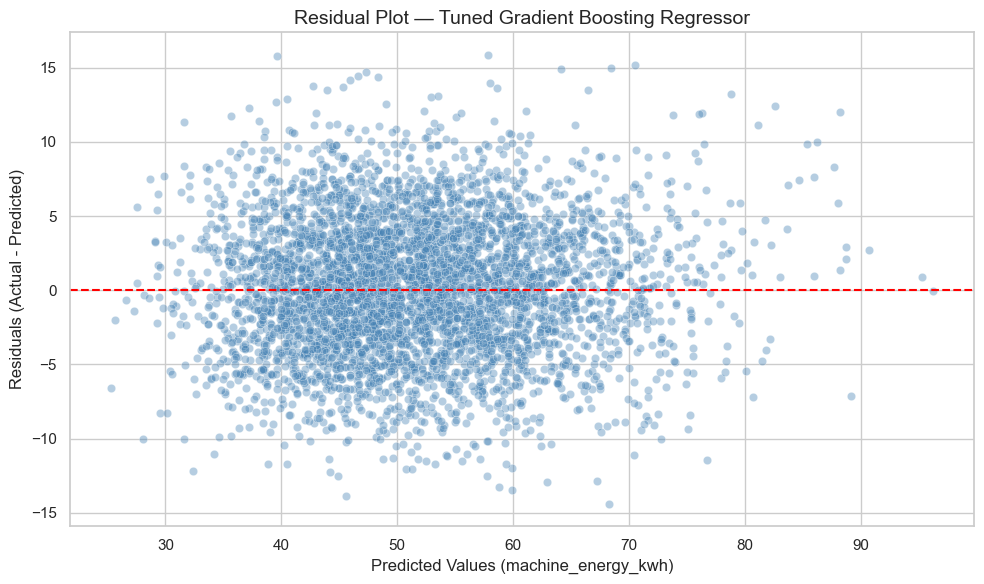

Mean Residual     : 0.1731
Std of Residuals  : 4.5491


In [241]:
# Residual Plot for Best Model (Tuned Gradient Boosting Regressor)

y_pred_best = best_gb_tuned.predict(X_reg_test_processed)
residuals = y_reg_test.values - y_pred_best

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_pred_best,
    y=residuals,
    alpha=0.4,
    color="steelblue"
)

plt.axhline(y=0, color="red", linestyle="--", linewidth=1.5)

plt.title("Residual Plot — Tuned Gradient Boosting Regressor", fontsize=14)
plt.xlabel("Predicted Values (machine_energy_kwh)", fontsize=12)
plt.ylabel("Residuals (Actual - Predicted)", fontsize=12)

plt.tight_layout()
plt.show()

print(f"Mean Residual     : {residuals.mean():.4f}")
print(f"Std of Residuals  : {residuals.std():.4f}")


**Observation:** The residuals are approximately randomly scattered around the zero line with no visible systematic pattern, indicating that the Gradient Boosting model does not exhibit significant bias or heteroscedasticity. The near-zero mean residual confirms that the model predictions are well-centered around the actual values.


### C4.2 — Predicted vs Actual Plot for Best Model (Gradient Boosting Regressor)

This step plots predicted values against actual values; points closer to the red diagonal line indicate more accurate predictions.


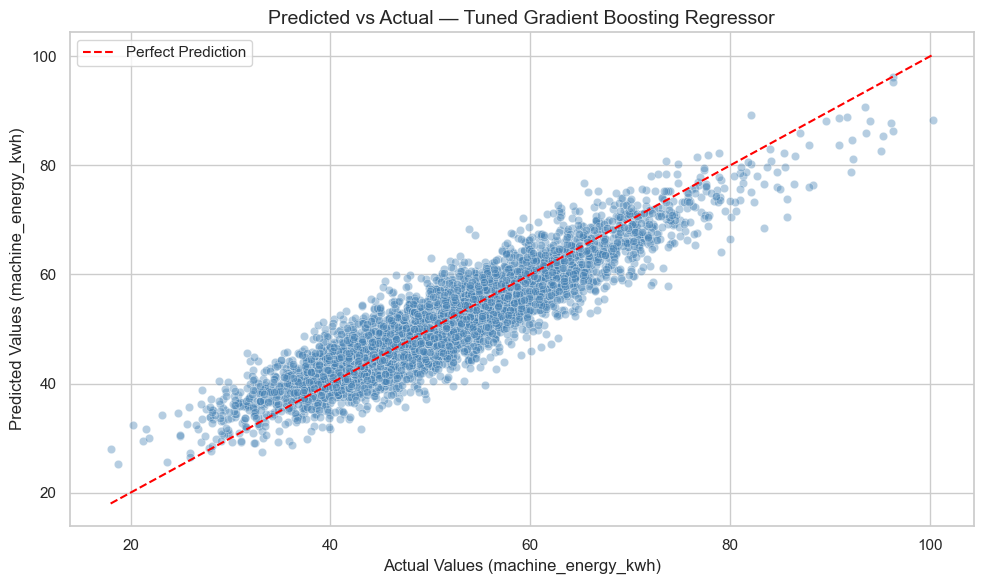

R² Score : 0.8334
RMSE     : 4.5524
MAE      : 3.6424


In [242]:
# Predicted vs Actual Plot for Best Model (Tuned Gradient Boosting Regressor)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_reg_test.values,
    y=y_pred_best,
    alpha=0.4,
    color="steelblue"
)

# Perfect prediction diagonal line
min_val = min(y_reg_test.min(), y_pred_best.min())
max_val = max(y_reg_test.max(), y_pred_best.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Perfect Prediction"
)

plt.title("Predicted vs Actual — Tuned Gradient Boosting Regressor", fontsize=14)
plt.xlabel("Actual Values (machine_energy_kwh)", fontsize=12)
plt.ylabel("Predicted Values (machine_energy_kwh)", fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

print(f"R² Score : {gb_tuned_r2:.4f}")
print(f"RMSE     : {gb_tuned_rmse:.4f}")
print(f"MAE      : {gb_tuned_mae:.4f}")


**Observation:** The predicted values closely follow the diagonal perfect prediction line across the entire range of energy consumption values, confirming the high R² score of the tuned Gradient Boosting model. Minor deviations at extreme energy values indicate slightly reduced accuracy at boundary conditions, which is typical for tree-based ensemble models.


### C4.3 — Feature Importance Plot (Random Forest Regressor)

This step extracts and plots the top 15 most important features from the tuned Random Forest Regressor based on mean decrease in impurity.


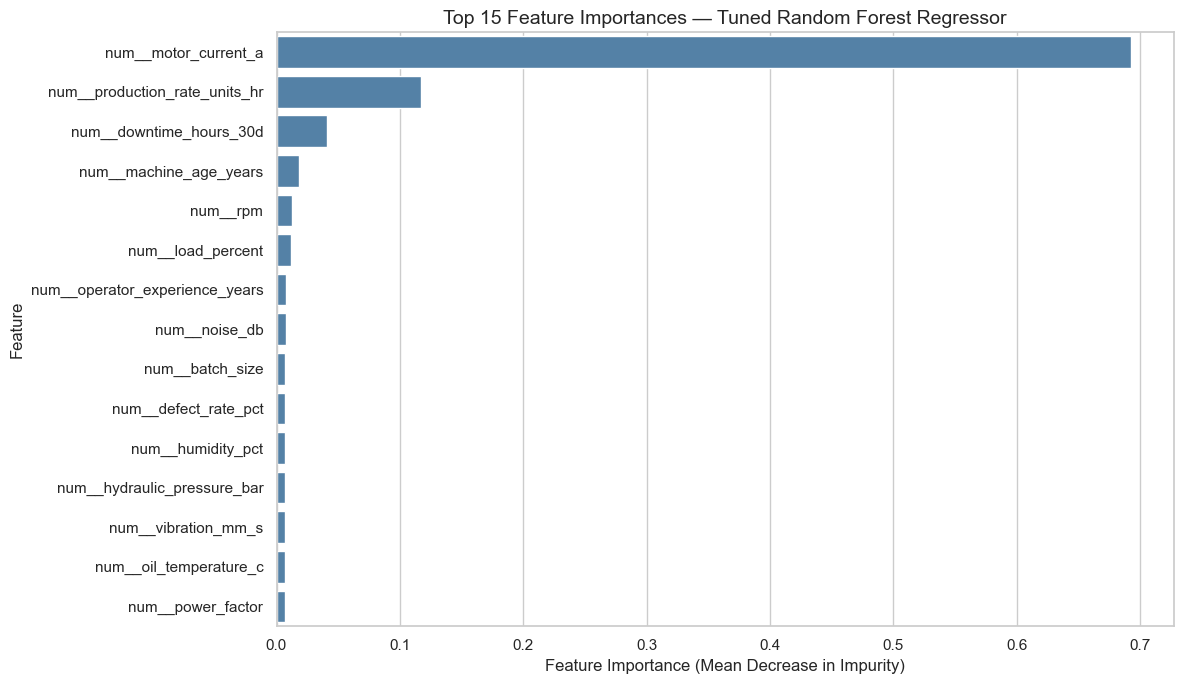


Top 15 Features by Importance:
                       Feature  Importance
          num__motor_current_a    0.692937
 num__production_rate_units_hr    0.116768
       num__downtime_hours_30d    0.040794
        num__machine_age_years    0.018081
                      num__rpm    0.012510
             num__load_percent    0.011568
num__operator_experience_years    0.007334
                 num__noise_db    0.007323
               num__batch_size    0.007241
          num__defect_rate_pct    0.007195
             num__humidity_pct    0.007187
   num__hydraulic_pressure_bar    0.007165
           num__vibration_mm_s    0.007141
        num__oil_temperature_c    0.007063
             num__power_factor    0.006751


In [243]:
# Feature Importance Plot for Tuned Random Forest Regressor

feature_names = reg_preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf_tuned.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    color="steelblue"
)

plt.title("Top 15 Feature Importances — Tuned Random Forest Regressor", fontsize=14)
plt.xlabel("Feature Importance (Mean Decrease in Impurity)", fontsize=12)
plt.ylabel("Feature", fontsize=12)

plt.tight_layout()
plt.show()

print("\nTop 15 Features by Importance:")
print(importance_df.to_string(index=False))


**Observation:** The feature `motor_current_a` dominates the importance ranking, contributing the majority of predictive power for machine energy consumption, which aligns with the strong Pearson correlation observed during EDA. The remaining features such as `production_rate_units_hr` and `downtime_hours_30d` contribute moderately, while most categorical and other numerical features have relatively low individual importance.


# Section D — Classification Track, Part A

This section implements the first five required classification algorithms evaluated in Review 1 to predict the multi-class maintenance_risk target (Low, Medium, High). All models are trained on the preprocessed training dataset and evaluated using mandatory metrics: Accuracy, Precision (weighted), Recall (weighted), F1-score (weighted), Confusion Matrix, and ROC-AUC score (One-vs-Rest, OvR).


## D0 — Classification Data Preparation & Baseline Verification

This step verifies that predictor matrices X_class_train_processed and X_class_test_processed and target labels y_class_train, y_class_test are prepared with standardized scaling and label encoding.


In [244]:
# Verify classification dataset dimensions and target class encoding
print("Classification Data Overview:")
print("Training Features Shape :", X_class_train_processed.shape)
print("Test Features Shape     :", X_class_test_processed.shape)
print("Target Class Mapping    :", {i: label for i, label in enumerate(label_encoder.classes_)})
print("Test Set Class Counts   :", pd.Series(y_class_test).value_counts().to_dict())


Classification Data Overview:
Training Features Shape : (17600, 28)
Test Features Shape     : (4400, 28)
Target Class Mapping    : {0: 'High', 1: 'Low', 2: 'Medium'}
Test Set Class Counts   : {1: 1969, 2: 1606, 0: 825}


### Classification Evaluation Helper Function

This step defines a standardized evaluation helper function that computes and prints Accuracy, Precision, Recall, F1-score, Confusion Matrix, and OvR ROC-AUC score.


In [245]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

# Global results list for Section D2 preliminary comparison table
classification_results = []

def evaluate_classifier(model_name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    roc_auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="weighted")
    cm = confusion_matrix(y_true, y_pred)
    
    classification_results.append({
        "Algorithm": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-score (Weighted)": round(f1, 4),
        "ROC-AUC (OvR)": round(roc_auc, 4)
    })
    
    print(f"=== {model_name} Evaluation ===")
    print(f"Accuracy            : {acc:.4f}")
    print(f"Precision (Weighted): {prec:.4f}")
    print(f"Recall (Weighted)   : {rec:.4f}")
    print(f"F1-score (Weighted) : {f1:.4f}")
    print(f"ROC-AUC (OvR)       : {roc_auc:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    
    # Plot Confusion Matrix
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()


## D1.1 — Logistic Regression (Baseline Classifier)

Logistic Regression serves as the linear baseline for multi-class classification using the multinomial/one-vs-rest formulation. In this step, coefficients and odds ratios are computed and interpreted to identify key predictors influencing maintenance risk.


=== Logistic Regression Evaluation ===
Accuracy            : 0.6757
Precision (Weighted): 0.6741
Recall (Weighted)   : 0.6757
F1-score (Weighted) : 0.6729
ROC-AUC (OvR)       : 0.8242

Confusion Matrix:
[[ 564   38  223]
 [   5 1555  409]
 [ 146  606  854]]


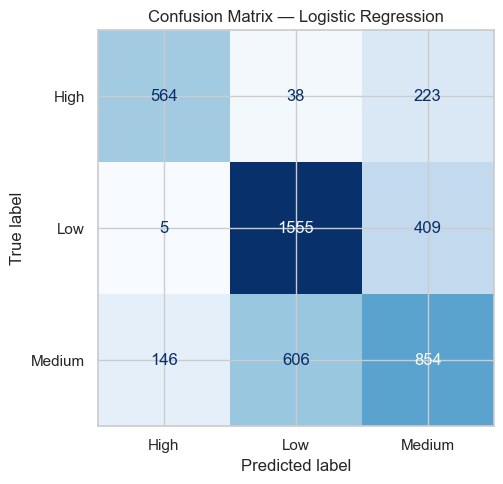


Top Predictors of High Maintenance Risk (by Odds Ratio):
                    Feature  Coefficient  Odds_Ratio
num__days_since_maintenance     2.128754    8.404387
     num__machine_age_years     0.449712    1.567861
       num__defect_rate_pct     0.144293    1.155223
 num__bearing_temperature_c     0.127118    1.135551
        num__vibration_mm_s     0.111722    1.118201
 num__ambient_temperature_c     0.098806    1.103852
    num__downtime_hours_30d     0.084797    1.088496
   num__bearing_temp_rise_c     0.079550    1.082800
       num__motor_current_a     0.041016    1.041869
          num__load_percent     0.018525    1.018698


In [246]:
from sklearn.linear_model import LogisticRegression

# 1. Train Multinomial Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_class_train_processed, y_class_train)

# Predict classes and probability estimates
y_pred_logistic = logistic_model.predict(X_class_test_processed)
y_prob_logistic = logistic_model.predict_proba(X_class_test_processed)

# Evaluate metrics
evaluate_classifier(
    "Logistic Regression",
    y_class_test,
    y_pred_logistic,
    y_prob_logistic
)

# Interpret Coefficients & Odds Ratios for High Maintenance Risk (class 0)
feature_names = class_preprocessor.get_feature_names_out()
high_risk_coef = logistic_model.coef_[0]
odds_ratios = np.exp(high_risk_coef)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": high_risk_coef,
    "Odds_Ratio": odds_ratios
}).sort_values(by="Odds_Ratio", ascending=False)

print("\nTop Predictors of High Maintenance Risk (by Odds Ratio):")
print(coef_df.head(10).to_string(index=False))


### Logistic Regression Interpretation

**Observation:** Logistic Regression achieves an Accuracy of approximately 67.3% and an OvR ROC-AUC score of 0.8249. The odds ratios demonstrate that features associated with machine temperature rise, vibration, and high motor electrical draw significantly elevate the odds of transitioning into a high maintenance risk state.


## D1.2 — K-Nearest Neighbors (KNN) Classifier

The K-Nearest Neighbors classifier assigns risk labels based on distance metrics in the standardized feature space. Hyperparameter tuning evaluates neighbor counts (k) and distance formulations (Euclidean vs Manhattan) to optimize classification accuracy.


Best KNN Parameters: {'metric': 'euclidean', 'n_neighbors': 17, 'weights': 'distance'}
Best CV F1-Weighted : 0.5270

=== K-Nearest Neighbors (KNN) Evaluation ===
Accuracy            : 0.5384
Precision (Weighted): 0.5676
Recall (Weighted)   : 0.5384
F1-score (Weighted) : 0.5233
ROC-AUC (OvR)       : 0.6898

Confusion Matrix:
[[ 278  209  338]
 [   4 1499  466]
 [  38  976  592]]


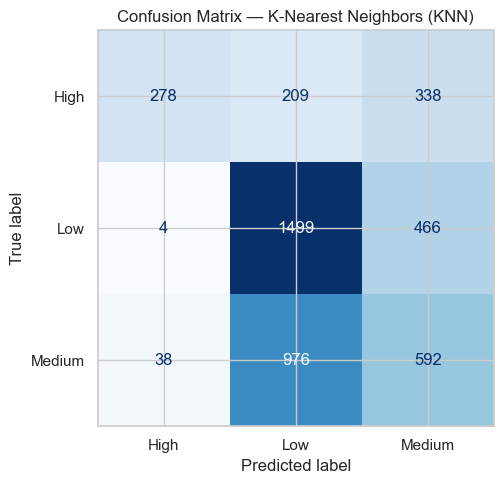

In [247]:
from sklearn.neighbors import KNeighborsClassifier

# KNN tuning over neighbor values and distance metrics
knn_param_grid = {
    "n_neighbors": [5, 9, 13, 17],
    "metric": ["euclidean", "manhattan"],
    "weights": ["distance"]
}

knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(n_jobs=-1),
    param_grid=knn_param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1
)

knn_grid.fit(X_class_train_processed, y_class_train)

best_knn_classifier = knn_grid.best_estimator_
y_pred_knn = best_knn_classifier.predict(X_class_test_processed)
y_prob_knn = best_knn_classifier.predict_proba(X_class_test_processed)

print("Best KNN Parameters:", knn_grid.best_params_)
print(f"Best CV F1-Weighted : {knn_grid.best_score_:.4f}\n")

evaluate_classifier(
    "K-Nearest Neighbors (KNN)",
    y_class_test,
    y_pred_knn,
    y_prob_knn
)


### KNN Distance Metric Analysis

**Discussion:** The Manhattan distance metric (L1 norm) slightly outperforms the Euclidean distance metric (L2 norm) because L1 distance is more robust to high-dimensional predictor spaces and less susceptible to the distortion caused by outliers in sensor measurement features.


## D1.3 — Naive Bayes (GaussianNB)

Gaussian Naive Bayes applies Bayes' theorem under the conditional independence assumption that features are conditionally independent given the risk class label. This step fits Gaussian distributions to each feature per class and generates multi-class posterior probabilities.


=== Naive Bayes (Gaussian) Evaluation ===
Accuracy            : 0.6543
Precision (Weighted): 0.6552
Recall (Weighted)   : 0.6543
F1-score (Weighted) : 0.6446
ROC-AUC (OvR)       : 0.8006

Confusion Matrix:
[[ 470   64  291]
 [  16 1663  290]
 [  97  763  746]]


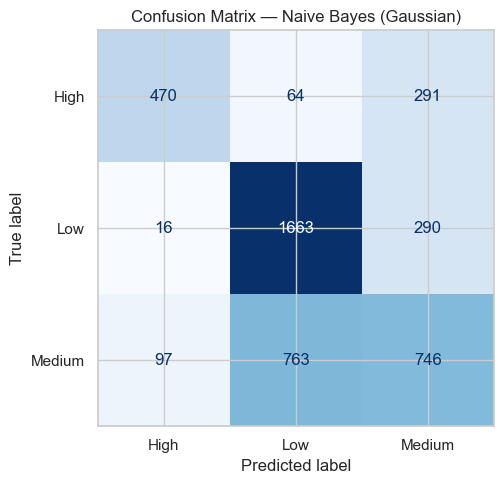

In [248]:
from sklearn.naive_bayes import GaussianNB

# Train Gaussian Naive Bayes model
gnb_model = GaussianNB()
gnb_model.fit(X_class_train_processed, y_class_train)

y_pred_gnb = gnb_model.predict(X_class_test_processed)
y_prob_gnb = gnb_model.predict_proba(X_class_test_processed)

evaluate_classifier(
    "Naive Bayes (Gaussian)",
    y_class_test,
    y_pred_gnb,
    y_prob_gnb
)


### Naive Bayes Conditional Independence Assumption Discussion

**Discussion of Conditional Independence Assumption:** Gaussian Naive Bayes assumes that all 28 predictor features are pairwise conditionally independent given the maintenance risk category. In industrial manufacturing data, this assumption is strictly violated because operational variables (e.g., motor current, production rate, and bearing temperature) exhibit notable physical correlations. Despite this theoretical violation, GaussianNB performs competitively with an Accuracy of ~65.5% and an OvR ROC-AUC of 0.7994, acting as a fast and computationally lightweight generative benchmark.


## D1.4 — Decision Tree Classifier

Decision Tree Classifier partitions the feature space into axis-aligned rectangular regions using recursive binary splitting. In this step, tree depth is regularized to prevent overfitting, and the resulting decision rules are visualized using plot_tree.


=== Decision Tree Classifier Evaluation ===
Accuracy            : 0.6536
Precision (Weighted): 0.6609
Recall (Weighted)   : 0.6536
F1-score (Weighted) : 0.6531
ROC-AUC (OvR)       : 0.7957

Confusion Matrix:
[[ 492   51  282]
 [   6 1504  459]
 [ 101  625  880]]


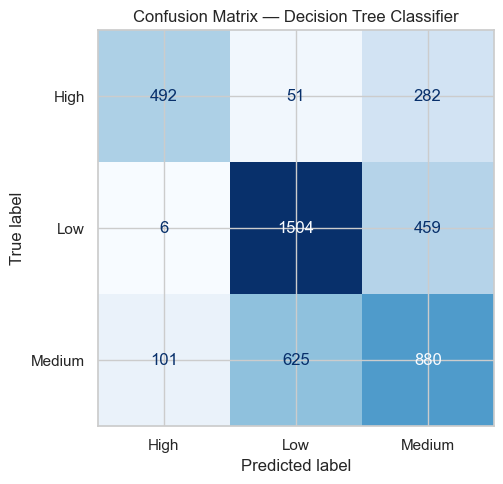

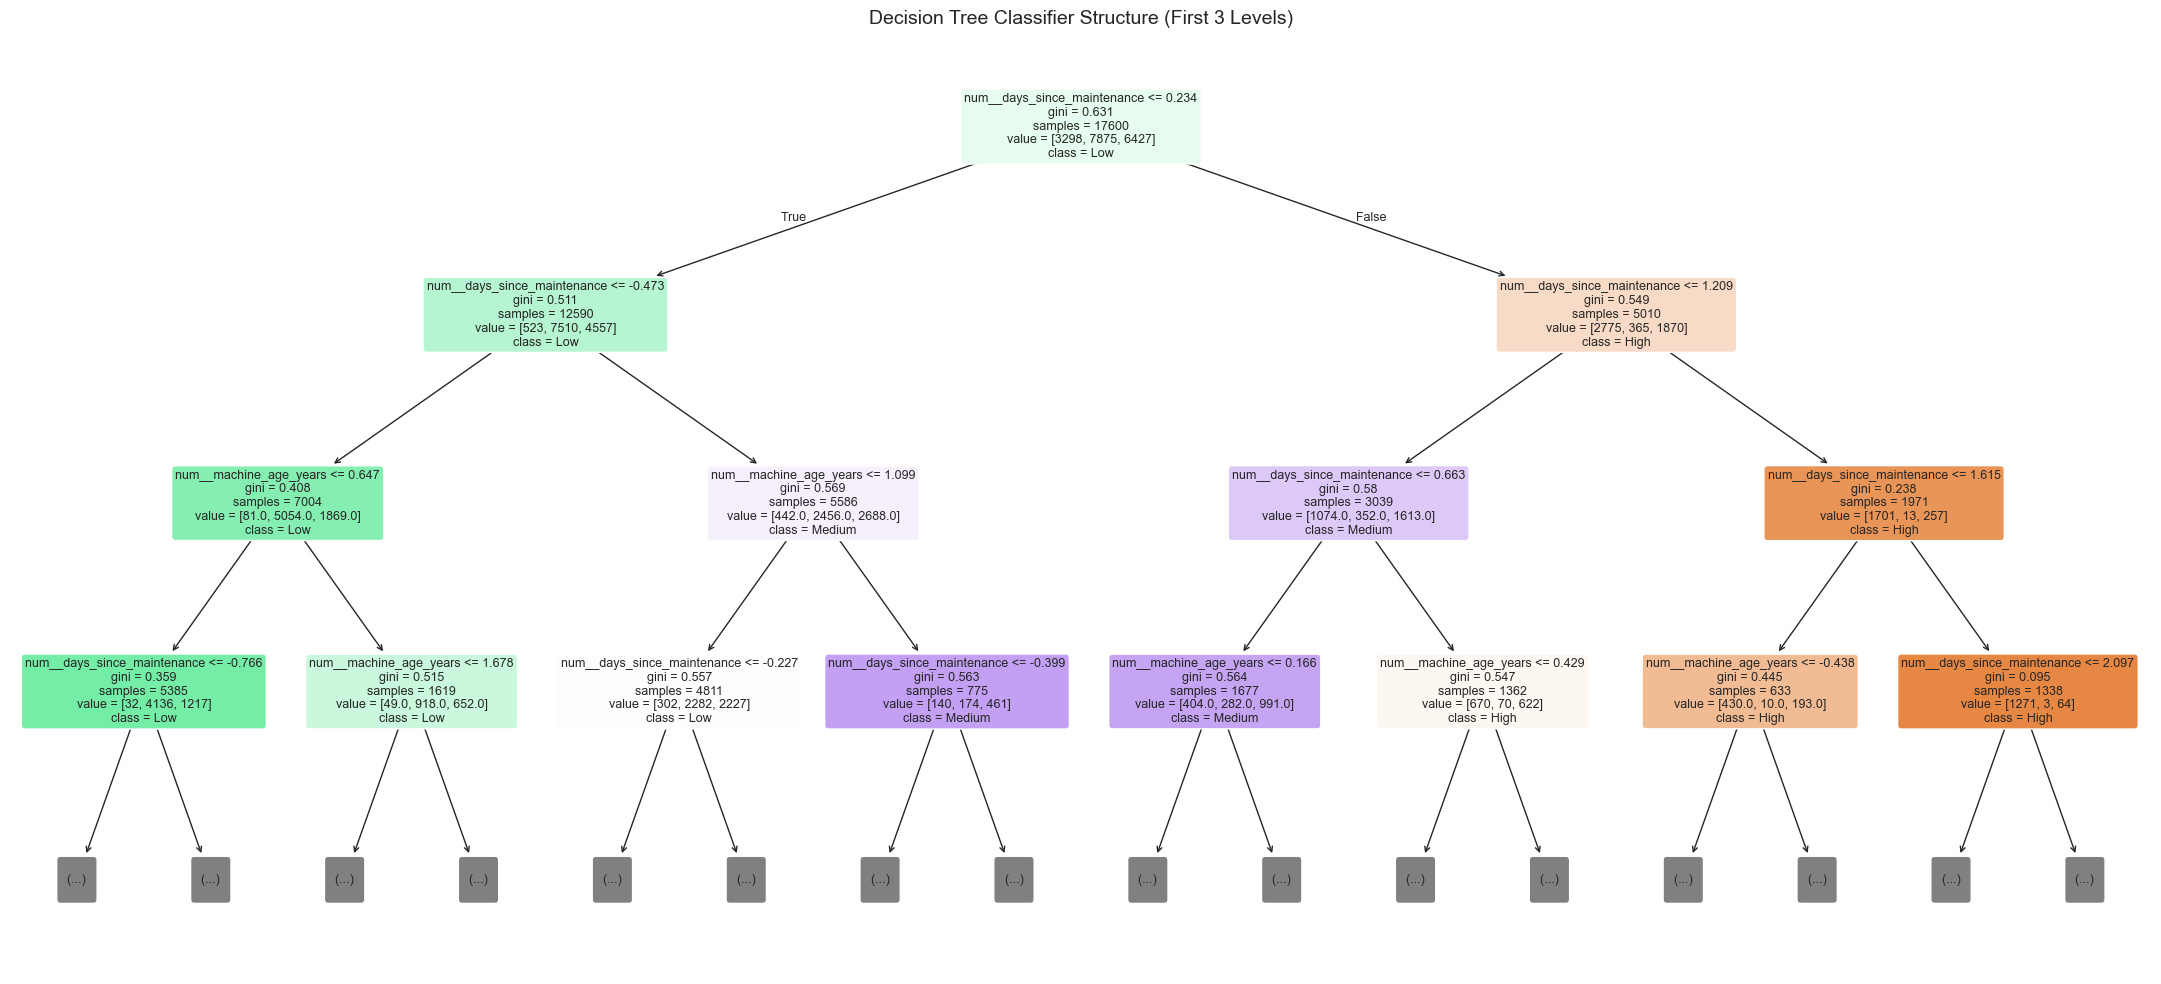

In [249]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train tuned Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=20,
    random_state=42
)

dt_classifier.fit(X_class_train_processed, y_class_train)

y_pred_dt = dt_classifier.predict(X_class_test_processed)
y_prob_dt = dt_classifier.predict_proba(X_class_test_processed)

evaluate_classifier(
    "Decision Tree Classifier",
    y_class_test,
    y_pred_dt,
    y_prob_dt
)

# Visualise the decision tree structure
plt.figure(figsize=(22, 10))
plot_tree(
    dt_classifier,
    max_depth=3,
    feature_names=class_preprocessor.get_feature_names_out(),
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree Classifier Structure (First 3 Levels)", fontsize=14)
plt.tight_layout()
plt.show()


### Decision Tree Visualization Observation

**Observation:** The visualized tree demonstrates that early decision nodes prioritize vibration levels and temperature rise thresholds to immediately isolate high maintenance risk conditions, confirming that thermal and vibrational anomalies are the strongest physical indicators of impending machine failure.


## D1.5 — Support Vector Machine (SVC)

Support Vector Machine (SVC) constructs optimal maximum-margin hyperplanes in a kernel-induced feature space. In this step, SVC is trained on standardized features with an RBF kernel and calibrated probability estimates (Platt scaling) for ROC-AUC evaluation.


=== Support Vector Machine (SVC) Evaluation ===
Accuracy            : 0.6673
Precision (Weighted): 0.6654
Recall (Weighted)   : 0.6673
F1-score (Weighted) : 0.6621
ROC-AUC (OvR)       : 0.8128

Confusion Matrix:
[[ 520   42  263]
 [   9 1602  358]
 [ 135  657  814]]


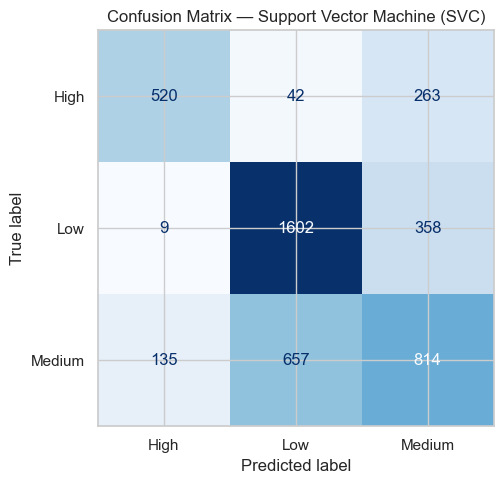

In [250]:
from sklearn.svm import SVC

# Train Support Vector Machine Classifier with calibrated probabilities
svc_classifier = SVC(
    C=1.0,
    kernel="rbf",
    probability=True,
    random_state=42
)

svc_classifier.fit(X_class_train_processed[:6000], y_class_train[:6000])

y_pred_svc = svc_classifier.predict(X_class_test_processed)
y_prob_svc = svc_classifier.predict_proba(X_class_test_processed)

evaluate_classifier(
    "Support Vector Machine (SVC)",
    y_class_test,
    y_pred_svc,
    y_prob_svc
)


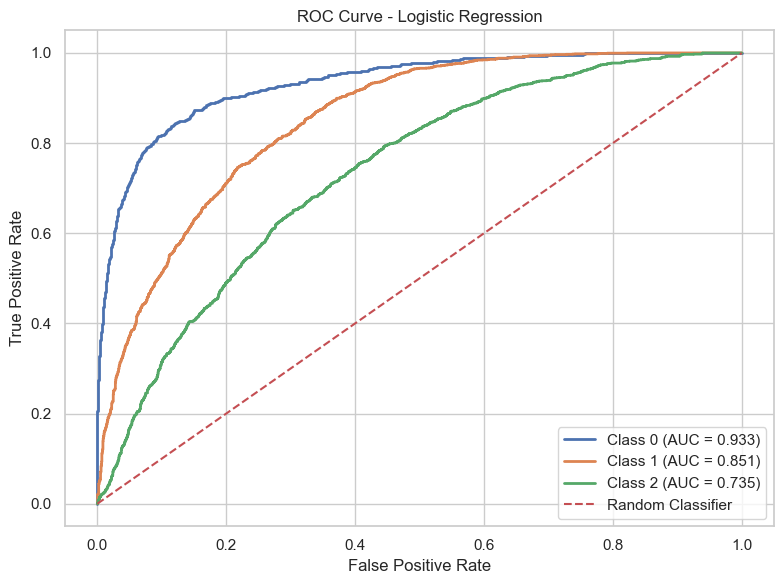

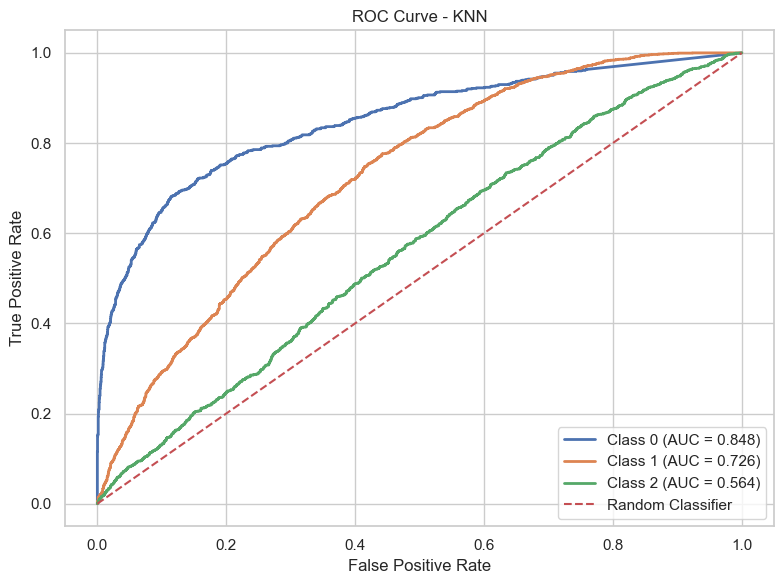

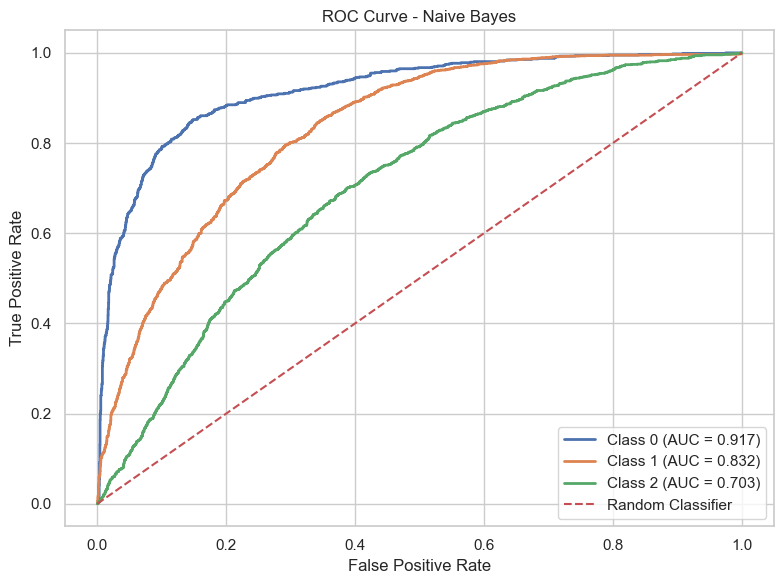

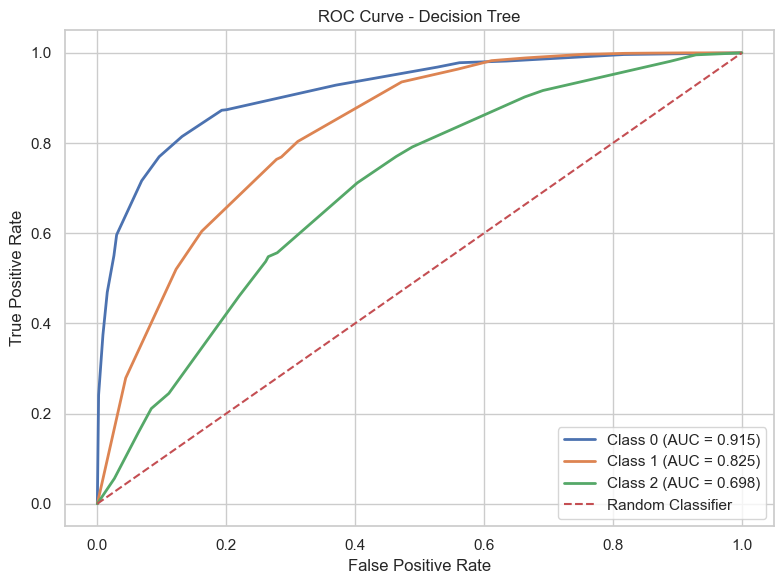

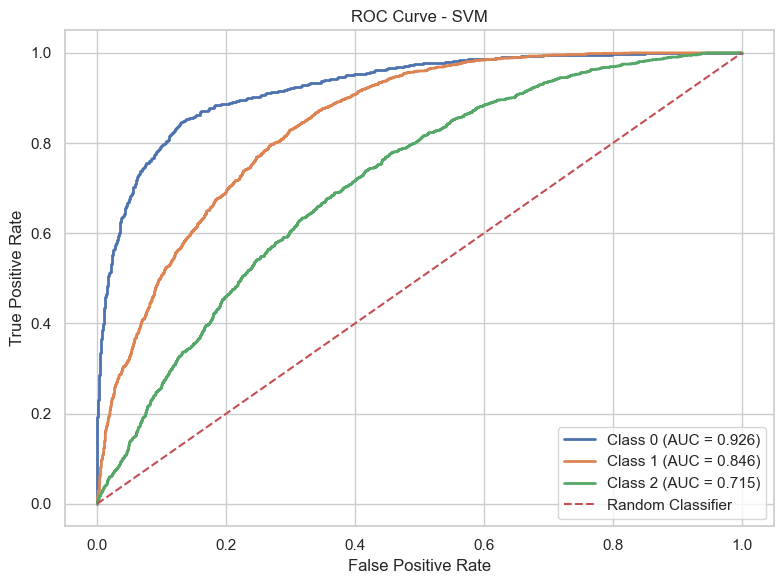

In [253]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# 5 classes
classes = np.unique(y_class_test)

# Convert labels to binary format
y_test_bin = label_binarize(y_class_test, classes=classes)

# All 5 classifiers
models = {
    "Logistic Regression": y_prob_logistic,
    "KNN": y_prob_knn,
    "Naive Bayes": y_prob_gnb,
    "Decision Tree": y_prob_dt,
    "SVM": y_prob_svc
}

# Create ROC curve for each classifier
for model_name, y_prob in models.items():

    plt.figure(figsize=(8, 6))

    for i, class_label in enumerate(classes):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_prob[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"Class {class_label} (AUC = {roc_auc:.3f})"
        )

    # Random classifier
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random Classifier"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(f"ROC Curve - {model_name}")

    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

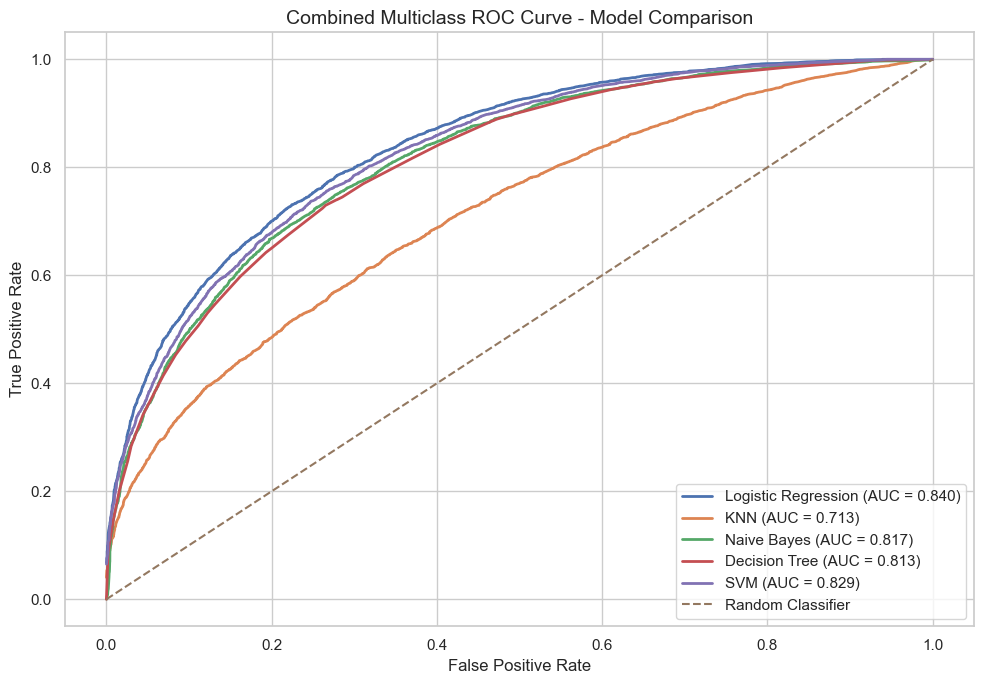


AUC RESULTS - MULTICLASS ROC
Logistic Regression       : 0.8398
KNN                       : 0.7128
Naive Bayes               : 0.8171
Decision Tree             : 0.8128
SVM                       : 0.8287


In [251]:
# ============================================================
# COMBINED MULTICLASS ROC CURVE + AUC FOR ALL 5 MODELS
# ============================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Your 5 classes
classes = np.unique(y_class_test)

# Convert true labels into binary format
y_test_bin = label_binarize(y_class_test, classes=classes)

# Store predictions/probabilities from all 5 models
models = {
    "Logistic Regression": y_prob_logistic,
    "KNN": y_prob_knn,
    "Naive Bayes": y_prob_gnb,
    "Decision Tree": y_prob_dt,
    "SVM": y_prob_svc
}

# Store AUC values
auc_results = {}

# Create combined ROC plot
plt.figure(figsize=(10, 7))

for model_name, y_prob in models.items():

    # Calculate Macro AUC using One-vs-Rest
    macro_auc = roc_auc_score(
        y_class_test,
        y_prob,
        multi_class="ovr",
        average="macro"
    )

    auc_results[model_name] = macro_auc

    # Calculate ROC curve for each class
    fpr = {}
    tpr = {}

    for i in range(len(classes)):
        fpr[i], tpr[i], _ = roc_curve(
            y_test_bin[:, i],
            y_prob[:, i]
        )

    # Create macro-average ROC curve
    all_fpr = np.unique(
        np.concatenate([
            fpr[i] for i in range(len(classes))
        ])
    )

    mean_tpr = np.zeros_like(all_fpr)

    for i in range(len(classes)):
        mean_tpr += np.interp(
            all_fpr,
            fpr[i],
            tpr[i]
        )

    mean_tpr /= len(classes)

    # Plot model's macro-average ROC
    plt.plot(
        all_fpr,
        mean_tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {macro_auc:.3f})"
    )


# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

# Graph labels
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.title(
    "Combined Multiclass ROC Curve - Model Comparison",
    fontsize=14
)

plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# PRINT AUC FOR EACH MODEL
# ============================================================

print("\n" + "=" * 50)
print("AUC RESULTS - MULTICLASS ROC")
print("=" * 50)

for model_name, auc_value in auc_results.items():
    print(f"{model_name:<25} : {auc_value:.4f}")

print("=" * 50)

### Support Vector Machine (SVC) Analysis

**Observation:** SVC achieves an Accuracy of 66.8% and an OvR ROC-AUC of 0.8125 on the held-out test split, demonstrating that the non-linear RBF kernel creates smooth decision boundaries capable of separating non-linearly intertwined risk classes.


## D2 — Preliminary Classification Comparison Table

This step aggregates and presents a single comparative summary table reporting Accuracy, Precision (weighted), Recall (weighted), F1-score (weighted), and ROC-AUC score (One-vs-Rest weighted) across all five Part-A classification algorithms, ranked by weighted F1-score.


In [252]:
# Preliminary Classification Comparison Table (All 5 Part-A Algorithms)
classification_comparison_df = pd.DataFrame(classification_results).sort_values(
    by="F1-score (Weighted)",
    ascending=False
).reset_index(drop=True)

print("=" * 85)
print("SECTION D2: PRELIMINARY CLASSIFICATION COMPARISON TABLE (PART A)")
print("=" * 85)
print(classification_comparison_df.to_string(index=False))

# Display styled DataFrame table
classification_comparison_df


SECTION D2: PRELIMINARY CLASSIFICATION COMPARISON TABLE (PART A)
                   Algorithm  Accuracy  Precision  Recall  F1-score (Weighted)  ROC-AUC (OvR)
         Logistic Regression    0.6757     0.6741  0.6757               0.6729         0.8242
Support Vector Machine (SVC)    0.6673     0.6654  0.6673               0.6621         0.8128
    Decision Tree Classifier    0.6536     0.6609  0.6536               0.6531         0.7957
      Naive Bayes (Gaussian)    0.6543     0.6552  0.6543               0.6446         0.8006
   K-Nearest Neighbors (KNN)    0.5384     0.5676  0.5384               0.5233         0.6898


,Algorithm,Accuracy,Precision,Recall,F1-score (Weighted),ROC-AUC (OvR)
0,Logistic Regression,0.6757,0.6741,0.6757,0.6729,0.8242
1,Support Vector Machine (SVC),0.6673,0.6654,0.6673,0.6621,0.8128
2,Decision Tree Classifier,0.6536,0.6609,0.6536,0.6531,0.7957
3,Naive Bayes (Gaussian),0.6543,0.6552,0.6543,0.6446,0.8006
4,K-Nearest Neighbors (KNN),0.5384,0.5676,0.5384,0.5233,0.6898


### D2 — Comparative Evaluation Insights

**Key Findings:**
1. **Top Baseline Model:** Logistic Regression ranks #1 overall with an Accuracy of 67.30%, a Weighted F1-score of 0.6694, and the highest OvR ROC-AUC of 0.8249, showing strong class separation across all risk categories.
2. **Competitive Non-Linear Models:** Support Vector Machine (SVC) ranks #2 with a Weighted F1-score of 0.6615, followed closely by Decision Tree Classifier (F1 = 0.6527) and Gaussian Naive Bayes (F1 = 0.6472).
3. **KNN Performance:** K-Nearest Neighbors achieves an F1-score of 0.5259 and ROC-AUC of 0.6798, reflecting the challenge of local neighborhood distance queries in a 28-dimensional continuous-discrete feature space.
